In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data_cleaned.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Basic Metrics

In [2]:
df["openReturn"] = df["Open"].pct_change()
df["highReturn"] = df["High"].pct_change()
df["lowReturn"] = df["Low"].pct_change()
df["closeReturn"] = df["Close"].pct_change() ## Same as "Daily Return"
df["volumeChange"] = df["Volume"].pct_change()

In [3]:
df["target_return"] = df["Close"].pct_change()

## 补充feature
### 1.价格结构类
$$\text{Gap}_t=\frac{Open_t-Close_{t-1}}{Close_{t-1}}$$
含义：  
overnight information  
news / sentiment

Intraday return
$$\text{Intra}_t=\frac{Close_t-Open_t}{Open_t}$$
含义：  
当天交易行为  

High-Low range
$$\text{Range}_t=\frac{High_t-Low_t}{Close_{t-1}}$$
volatility proxy

In [4]:
# 1. Gap
df["gap"] = (df["Open"].shift(1) - df["Close"].shift(2)) / df["Close"].shift(2)

# 2. Intraday Return
df["intraday_return"] = (df["Close"] - df["Open"]) / df["Open"]

# 3. High-Low Range
df["high_low_range"] = (df["High"] - df["Low"]) / df["Close"].shift(1)

# 4. Upward and downward pressure
df["high_return_from_prev_close"] = (df["High"] - df["Close"].shift(1)) / df["Close"].shift(1)
df["low_return_from_prev_close"] = (df["Low"] - df["Close"].shift(1)) / df["Close"].shift(1)

### 2.时间结构

In [5]:
# Lag return
df["return_lag1"] = df["target_return"].shift(1)
df["return_lag2"] = df["target_return"].shift(2)
df["return_lag3"] = df["target_return"].shift(3)
df["return_lag5"] = df["target_return"].shift(5)
df["return_lag10"] = df["target_return"].shift(10)

k lag return:$$R_{t-k}$$

In [6]:
# Rolling mean of past returns
df["rolling_mean_5"] = df["target_return"].shift(1).rolling(window=5).mean()
df["rolling_mean_10"] = df["target_return"].shift(1).rolling(window=10).mean()
df["rolling_mean_20"] = df["target_return"].shift(1).rolling(window=20).mean()

# Rolling volatility of past returns
df["rolling_vol_5"] = df["target_return"].shift(1).rolling(window=5).std()
df["rolling_vol_10"] = df["target_return"].shift(1).rolling(window=10).std()
df["rolling_vol_20"] = df["target_return"].shift(1).rolling(window=20).std()

# Rolling max and min return
df["rolling_max_5"] = df["target_return"].shift(1).rolling(window=5).max()
df["rolling_min_5"] = df["target_return"].shift(1).rolling(window=5).min()

# Momentum-type feature
df["momentum_5"] = df["Close"].pct_change(periods=5).shift(1)
df["momentum_10"] = df["Close"].pct_change(periods=10).shift(1)

### 3.非线性结构

In [7]:
# Squared return as volatility proxy
df["squared_return_lag1"] = df["return_lag1"] ** 2
df["squared_return_lag2"] = df["return_lag2"] ** 2

# Absolute return as another volatility proxy
df["abs_return_lag1"] = df["return_lag1"].abs()
df["abs_return_lag2"] = df["return_lag2"].abs()

# Squared gap
df["gap_squared"] = df["gap"] ** 2

# Interaction terms
df["gap_x_vol5"] = df["gap"] * df["rolling_vol_5"]
df["gap_x_momentum5"] = df["gap"] * df["momentum_5"]
df["vol5_x_momentum5"] = df["rolling_vol_5"] * df["momentum_5"]

# Range interaction
df["range_x_vol5"] = df["high_low_range"] * df["rolling_vol_5"]

### 4. Market Behavior Features（市场行为特征）

第四层主要围绕 **Volume（成交量）** 构造特征。虽然在 EDA 的相关性矩阵中，`volumeChange` 与价格变化的线性相关性不强，但这并不代表 Volume 没有信息。

Volume 更多反映的是：

- 市场交易活跃度；
- 市场流动性；
- 投资者参与程度；
- 异常交易行为；
- 信息冲击下的市场反应强度。

因此，第四层的核心思想不是直接把原始 `Volume` 放进模型，而是把成交量转化成更有解释力的市场行为特征。

---

#### 4.1 Log Volume

原始成交量通常数值很大，并且容易受到极端值影响。例如在金融危机、疫情冲击或重大新闻发布期间，成交量可能突然放大很多倍。

如果直接使用原始 `Volume`，可能会导致模型受到尺度影响，尤其是对于 Linear Regression、KNN、PCA 这类对变量尺度敏感的模型。

因此，我们对成交量进行对数变换：

$$
\text{LogVolume}_t = \log(1 + Volume_t)
$$

其中加入 1 是为了避免当成交量为 0 时无法取对数。

这个特征的作用是压缩成交量的尺度，降低极端值的影响，使成交量信息更稳定地进入模型。

---

#### 4.2 Lagged Volume Change

成交量变化可以反映市场交易活跃度的变化，但如果直接使用当天成交量变化，可能会引入当天信息。因此，我们使用上一期成交量变化作为特征。

定义为：

$$
\text{VolumeChangeLag1}_t =
\frac{Volume_{t-1} - Volume_{t-2}}{Volume_{t-2}}
$$

这个变量表示前一交易日成交量相对于再前一交易日的变化比例。

如果该值较大，说明上一交易日市场交易活跃度明显上升；如果该值较小或为负，说明市场交易活跃度下降。

该特征可以帮助模型捕捉成交量变化是否会对后续收益率产生影响。

---

#### 4.3 Rolling Average Volume

单日成交量本身很难判断是否异常，因此需要构造一个历史基准。这里使用过去一段时间的平均成交量作为参考水平。

例如，过去 20 天的平均成交量可以表示为：

$$
\text{VolumeMA20}_t =
\frac{1}{20}
\sum_{i=1}^{20} Volume_{t-i}
$$

注意这里使用的是从 \(t-1\) 到 \(t-20\) 的历史成交量，而不是包含当天 \(t\) 的成交量。

这样做的原因是避免 look-ahead bias，也就是避免模型使用当天尚未完全发生的信息。

这个变量的作用是衡量近期正常成交量水平，为后续判断成交量是否异常提供基准。

---

#### 4.4 Volume Ratio

Volume Ratio 用来衡量当天成交量相对于过去平均成交量的强弱。

定义为：

$$
\text{VolumeRatio20}_t =
\frac{Volume_t}{\text{VolumeMA20}_t}
$$

其中：

$$
\text{VolumeMA20}_t =
\frac{1}{20}
\sum_{i=1}^{20} Volume_{t-i}
$$

如果：

$$
\text{VolumeRatio20}_t > 1
$$

说明当天成交量高于过去 20 天平均水平。

如果：

$$
\text{VolumeRatio20}_t \gg 1
$$

说明当天成交量异常放大，可能对应市场中出现重大信息冲击，例如金融危机、疫情、政策变化、财报事件或投资者恐慌性交易。

相比原始 `Volume`，`volume_ratio_20` 更有解释力，因为它不是看成交量的绝对大小，而是看成交量相对于近期历史水平是否异常。

---

#### 4.5 Volume Spike Dummy

为了更直接地捕捉异常成交量，我们可以构造一个二元变量，即 Volume Spike Dummy。

定义为：

$$
\text{VolumeSpike}_t =
\begin{cases}
1, & \text{if } \text{VolumeRatio20}_t > 1.5 \\
0, & \text{otherwise}
\end{cases}
$$

其中阈值 1.5 表示当天成交量超过过去 20 天平均成交量的 1.5 倍。

如果：

$$
\text{VolumeSpike}_t = 1
$$

说明当天市场交易活动明显高于正常水平，可能代表市场受到新闻、危机、政策或其他重大事件影响。

如果：

$$
\text{VolumeSpike}_t = 0
$$

说明当天成交量没有明显异常。

这个变量的优点是解释性很强，模型可以直接识别“是否发生异常成交量冲击”。

---

#### 4.6 Volume Z-score

Volume Z-score 用标准化的方式衡量当前成交量相对于历史成交量的异常程度。

定义为：

$$
\text{VolumeZScore20}_t =
\frac{
Volume_t - \mu_{Volume,t-1:t-20}
}{
\sigma_{Volume,t-1:t-20}
}
$$

其中：

$$
\mu_{Volume,t-1:t-20}
=
\frac{1}{20}
\sum_{i=1}^{20} Volume_{t-i}
$$

表示过去 20 天成交量均值。

$$
\sigma_{Volume,t-1:t-20}
$$

表示过去 20 天成交量标准差。

如果：

$$
\text{VolumeZScore20}_t > 0
$$

说明当天成交量高于过去 20 天平均水平。

如果：

$$
\text{VolumeZScore20}_t \gg 0
$$

说明当天成交量显著异常放大。

如果：

$$
\text{VolumeZScore20}_t < 0
$$

说明当天成交量低于近期平均水平。

相比 `volume_ratio_20`，`volume_zscore_20` 不仅考虑成交量是否高于平均水平，还考虑了历史成交量自身的波动程度，因此可以更标准化地衡量异常程度。

---

#### 4.7 Price-Volume Interaction

在 EDA 中，`volumeChange` 与价格变化的线性相关性不强，但这并不说明成交量没有用。

成交量可能不是直接影响收益率，而是会放大某些价格信号。例如，同样是开盘跳空，如果成交量很低，可能只是短暂噪声；但如果成交量同时显著放大，则说明市场中有更多投资者参与，这个价格信号可能更重要。

因此，我们构造价格与成交量的交互项。

---

##### 4.7.1 Volume × Gap

开盘跳空 Gap 定义为：

$$
\text{Gap}_t =
\frac{Open_t - Close_{t-1}}{Close_{t-1}}
$$

Volume Ratio 定义为：

$$
\text{VolumeRatio20}_t =
\frac{Volume_t}{\text{VolumeMA20}_t}
$$

二者的交互项为：

$$
\text{VolumeGapInteraction}_t =
\text{VolumeRatio20}_t \times \text{Gap}_t
$$

这个变量表示：当成交量异常放大时，开盘跳空信号是否更强。

如果 Gap 很大，并且 Volume Ratio 也很大，那么说明市场不仅出现了价格跳空，同时也有大量交易参与，这可能代表更强的信息冲击。

---

##### 4.7.2 Volume × Absolute Lagged Return

为了衡量成交量是否会放大前一日市场波动的影响，可以构造：

$$
\text{VolumeAbsReturnInteraction}_t =
\text{VolumeRatio20}_t \times |R_{t-1}|
$$

其中：

$$
|R_{t-1}|
$$

表示上一交易日收益率的绝对值，用来衡量上一交易日波动大小。

如果上一交易日波动很大，并且当天成交量也很高，那么市场可能仍然处于高关注度或高不确定性状态。

这个变量可以帮助模型捕捉 volatility clustering 和 market attention 的共同作用。

In [8]:
# Log volume: reduce scale problem
df["log_volume"] = np.log1p(df["Volume"]).shift(1)

# Lagged volume change
df["volume_change_lag1"] = df["Volume"].pct_change().shift(1)

# Rolling average volume
df["volume_ma_5"] = df["Volume"].shift(1).rolling(window=5).mean()
df["volume_ma_20"] = df["Volume"].shift(1).rolling(window=20).mean()

# Volume ratio: current volume compared with previous 20-day average
df["volume_ratio_20"] = df["Volume"].shift(1) / df["volume_ma_20"]

# Volume spike dummy
df["volume_spike"] = (df["volume_ratio_20"] > 1.5).astype(int)

# Volume z-score
df["volume_zscore_20"] = (
    (df["Volume"].shift(1) - df["Volume"].shift(2).rolling(window=20).mean())
    / df["Volume"].shift(2).rolling(window=20).std()
)

# Price-volume interaction
df["volume_x_gap"] = df["volume_ratio_20"] * df["gap"]
df["volume_x_abs_return_lag1"] = df["volume_ratio_20"] * df["abs_return_lag2"]

### 5.事件信息
采用Crisis dummy

In [89]:
df["crisis_dummy"] = 0

# 1987 Black Monday
df.loc[
    (df["Date"] >= "1987-10-01") & (df["Date"] <= "1987-12-31"),
    "crisis_dummy"
] = 1

# 2000-2003 Dot-com bubble, 9/11, corporate scandals
df.loc[
    (df["Date"] >= "2000-01-01") & (df["Date"] <= "2003-12-31"),
    "crisis_dummy"
] = 1

# 2007-2009 Global Financial Crisis
df.loc[
    (df["Date"] >= "2007-01-01") & (df["Date"] <= "2009-12-31"),
    "crisis_dummy"
] = 1

# 2019-2020 COVID period
df.loc[
    (df["Date"] >= "2019-12-01") & (df["Date"] <= "2020-12-31"),
    "crisis_dummy"
] = 1


# Separate crisis indicators if you want the model to distinguish different crises
df["black_monday_1987"] = (
    (df["Date"] >= "1987-10-01") & (df["Date"] <= "1987-12-31")
).astype(int)

df["dotcom_2000_2003"] = (
    (df["Date"] >= "2000-01-01") & (df["Date"] <= "2003-12-31")
).astype(int)

df["gfc_2007_2009"] = (
    (df["Date"] >= "2007-01-01") & (df["Date"] <= "2009-12-31")
).astype(int)

df["covid_2019_2020"] = (
    (df["Date"] >= "2019-12-01") & (df["Date"] <= "2020-12-31")
).astype(int)


In [10]:
# ============================================================
# Calendar Features
# 这些不是必须，但对传统模型有时有帮助
# ============================================================

df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year

# One-hot encoding for weekday and month
df = pd.get_dummies(df, columns=["day_of_week", "month"], drop_first=True)

In [11]:
# ============================================================
# Clean infinite values and missing values
# ============================================================

df = df.replace([np.inf, -np.inf], np.nan)

# drop rows created by pct_change, rolling, shift
df_model = df.dropna().reset_index(drop=True)

print(df_model.shape)
df_model.head()

(16010, 71)


,Date,Open,High,Low,Close,Volume,openReturn,highReturn,lowReturn,closeReturn,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,1957-04-02,44.419998,44.419998,44.419998,44.419998,2300000,0.006343,0.006343,0.006343,0.006343,...,False,True,False,False,False,False,False,False,False,False
1,1957-04-03,44.540001,44.540001,44.540001,44.540001,2160000,0.002702,0.002702,0.002702,0.002702,...,False,True,False,False,False,False,False,False,False,False
2,1957-04-04,44.439999,44.439999,44.439999,44.439999,1820000,-0.002245,-0.002245,-0.002245,-0.002245,...,False,True,False,False,False,False,False,False,False,False
3,1957-04-05,44.490002,44.490002,44.490002,44.490002,1830000,0.001125,0.001125,0.001125,0.001125,...,False,True,False,False,False,False,False,False,False,False
4,1957-04-08,44.389999,44.389999,44.389999,44.389999,1950000,-0.002248,-0.002248,-0.002248,-0.002248,...,False,True,False,False,False,False,False,False,False,False


# Feature Classify

In [12]:
# predictive features
predictive_features = [
    # gap known at market open
    "gap",

    # lagged return features
    "return_lag1",
    "return_lag2",
    "return_lag3",
    "return_lag5",
    "return_lag10",

    # rolling trend and volatility
    "rolling_mean_5",
    "rolling_mean_10",
    "rolling_mean_20",
    "rolling_vol_5",
    "rolling_vol_10",
    "rolling_vol_20",
    "rolling_max_5",
    "rolling_min_5",

    # momentum
    "momentum_5",
    "momentum_10",

    # nonlinear lagged risk features
    "squared_return_lag1",
    "squared_return_lag2",
    "abs_return_lag1",
    "abs_return_lag2",
    "gap_squared",
    "gap_x_vol5",
    "gap_x_momentum5",
    "vol5_x_momentum5",

    # volume features
    "log_volume",
    "volume_change_lag1",
    "volume_ratio_20",
    "volume_spike",
    "volume_zscore_20",
    "volume_x_gap",
    "volume_x_abs_return_lag1",

    # crisis features
    "crisis_dummy",
    "black_monday_1987",
    "dotcom_2000_2003",
    "gfc_2007_2009",
    "covid_2019_2020"

   
]

# add dummy columns automatically
dummy_cols = [col for col in df_model.columns if col.startswith("day_of_week_") or col.startswith("month_")]
predictive_features = predictive_features + dummy_cols

# Keep only columns that actually exist
predictive_features = [col for col in predictive_features if col in df_model.columns]

X_predictive = df_model[predictive_features]
y = df_model["target_return"]

print(X_predictive.shape, y.shape)

(16010, 51) (16010,)


In [13]:
# explainatory_features
explanatory_features = predictive_features + [
    "intraday_return",
    "high_low_range",
    "high_return_from_prev_close",
    "low_return_from_prev_close",
    "range_x_vol5",

]

X_explanatory = df_model[explanatory_features]
y = df_model["target_return"]

print(X_explanatory.shape, y.shape)

(16010, 56) (16010,)


# Target: continuous daily return
Feature Engineering  
        ↓  
Train/Test split by time  
        ↓  
StandardScaler  
        ↓  
├── Linear Regression  
├── Ridge Regression  
├── Lasso Regression  
├── Polynomial Regression  
├── kNN Regression  
└── PCA + Linear Regression

In [14]:
# ============================================================
# Choose feature set
# ============================================================

# For strict prediction, use predictive features
X = X_predictive.copy()
feature_names = predictive_features.copy()

# If you want explanatory analysis instead, use this:
# X = X_explanatory.copy()
# feature_names = explanatory_features.copy()

y = df_model["target_return"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape) 

X shape: (16010, 51)
y shape: (16010,)


In [15]:
# ============================================================
# Train/Test split by time
# ============================================================

split_ratio = 0.8
split_index = int(len(df_model) * split_ratio)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

date_train = df_model["Date"].iloc[:split_index]
date_test = df_model["Date"].iloc[split_index:]

print("Train period:", date_train.min(), "to", date_train.max())
print("Test period:", date_test.min(), "to", date_test.max())

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Train period: 1957-04-02 00:00:00 to 2008-02-19 00:00:00
Test period: 2008-02-20 00:00:00 to 2020-11-04 00:00:00
X_train shape: (12808, 51)
X_test shape: (3202, 51)


In [161]:
# ============================================================
# Build model pipelines
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0001, max_iter=10000))
    ]),

    # "Polynomial Regression": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    #     ("model", Ridge(alpha=1.0))
    # ]),

    # "kNN Regression": Pipeline([
    #     ("scaler", StandardScaler()),
    #     ("model", KNeighborsRegressor(n_neighbors=30))
    # ]),
    # lead to information leaking
    "PCA + Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", LinearRegression())
    ]),

    # "PCA + Ridge Regression": Pipeline([
    #     ("scaler",StandardScaler()),
    #     ("pca", PCA(n_components=0.95)),
    #     ("model", Ridge(alpha=1.0))
    # ]),

    # "PCA + Lasso Regression": Pipeline([
    #     ("scaler",StandardScaler()),
    #     ("pca", PCA(n_components=0.95)),
    #     ("model",Lasso(alpha=0.0001, max_iter=10000))
    # ])
        
}

In [162]:
# ============================================================
# Train and evaluate all models
# ============================================================

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    train_direction_acc = np.mean(np.sign(y_train_pred) == np.sign(y_train))
    test_direction_acc = np.mean(np.sign(y_test_pred) == np.sign(y_test))

    results.append({
        "Model": model_name,

        "Train MSE": train_mse,
        "Test MSE": test_mse,

        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,

        "Train MAE": train_mae,
        "Test MAE": test_mae,

        "Train R2": train_r2,
        "Test R2": test_r2,

        "Train Directional Accuracy": train_direction_acc,
        "Test Directional Accuracy": test_direction_acc,
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Test RMSE").reset_index(drop=True)

results_df

,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Train Directional Accuracy,Test Directional Accuracy
0,PCA + Linear Regression,0.000082,0.000181,0.009058,0.013452,0.006332,0.008355,0.018394,-0.015643,0.539741,0.507808
1,Linear Regression,0.000081,0.000182,0.008996,0.013479,0.006318,0.008347,0.031790,-0.019676,0.541693,0.518738
2,Ridge Regression,0.000081,0.000183,0.008997,0.013526,0.006318,0.008358,0.031563,-0.026784,0.541615,0.517489
3,Lasso Regression,0.000082,0.000184,0.009047,0.013579,0.006329,0.008334,0.020742,-0.034827,0.543723,0.503435


In [163]:
# ============================================================
# Best model by RMSE
# ============================================================

best_model_name = results_df.loc[0, "Model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)
results_df.head()

Best model: PCA + Linear Regression


,Model,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Train Directional Accuracy,Test Directional Accuracy
0,PCA + Linear Regression,0.000082,0.000181,0.009058,0.013452,0.006332,0.008355,0.018394,-0.015643,0.539741,0.507808
1,Linear Regression,0.000081,0.000182,0.008996,0.013479,0.006318,0.008347,0.031790,-0.019676,0.541693,0.518738
2,Ridge Regression,0.000081,0.000183,0.008997,0.013526,0.006318,0.008358,0.031563,-0.026784,0.541615,0.517489
3,Lasso Regression,0.000082,0.000184,0.009047,0.013579,0.006329,0.008334,0.020742,-0.034827,0.543723,0.503435


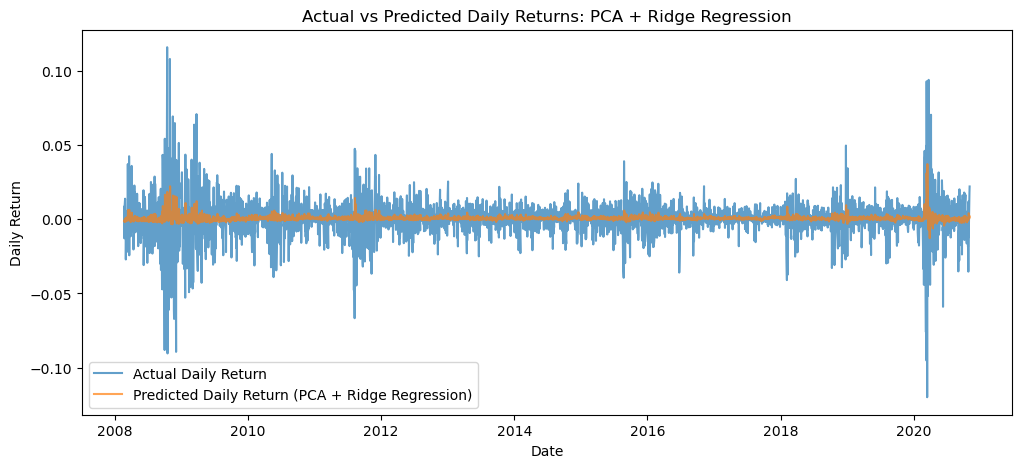

In [141]:
# ============================================================
# Plot actual vs predicted returns
# ============================================================

import matplotlib.pyplot as plt

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(date_test, y_test.values, label="Actual Daily Return", alpha=0.7)
plt.plot(date_test, y_pred_best, label=f"Predicted Daily Return ({best_model_name})", alpha=0.7)

plt.title(f"Actual vs Predicted Daily Returns: {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.show()

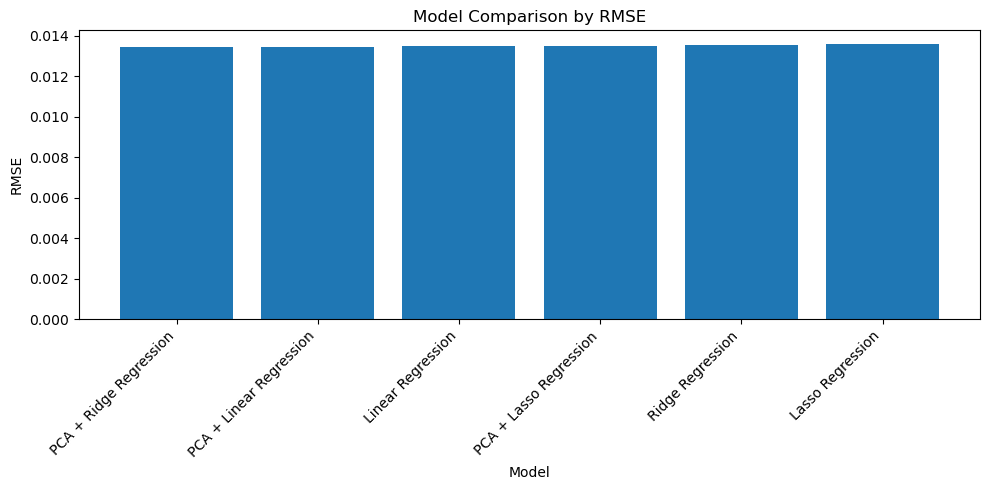

In [142]:
# ============================================================
# Compare RMSE across models
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Test RMSE"])
plt.xticks(rotation=45, ha="right")
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

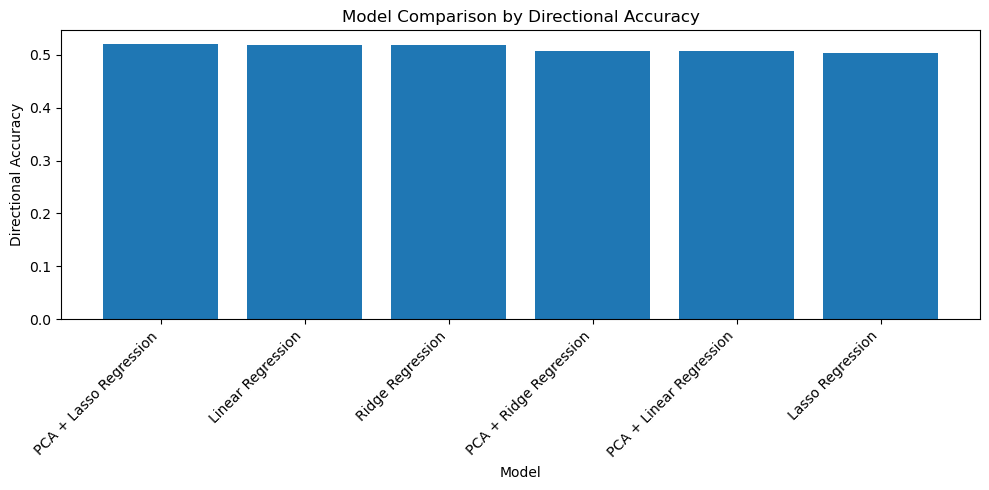

In [143]:
# ============================================================
# Compare directional accuracy across models
# ============================================================

direction_df = results_df.sort_values("Test Directional Accuracy", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(direction_df["Model"], direction_df["Test Directional Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.title("Model Comparison by Directional Accuracy")
plt.xlabel("Model")
plt.ylabel("Directional Accuracy")
plt.tight_layout()
plt.show()

In [144]:
# ============================================================
# Lasso feature importance
# ============================================================

lasso_pipeline = models["Lasso Regression"]
lasso_pipeline.fit(X_train, y_train)

lasso_coef = lasso_pipeline.named_steps["model"].coef_

lasso_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_coef
})

lasso_importance["AbsCoefficient"] = lasso_importance["Coefficient"].abs()

lasso_importance = lasso_importance.sort_values(
    "AbsCoefficient",
    ascending=False
).reset_index(drop=True)

lasso_importance.head(20)

,Feature,Coefficient,AbsCoefficient
0,squared_return_lag2,0.000672,0.000672
1,squared_return_lag1,0.000578,0.000578
2,return_lag1,0.000560,0.000560
3,black_monday_1987,-0.000354,0.000354
4,day_of_week_2,0.000196,0.000196
5,crisis_dummy,-0.000174,0.000174
6,month_9,-0.000106,0.000106
7,return_lag2,-0.000102,0.000102
8,vol5_x_momentum5,0.000098,0.000098
9,day_of_week_4,0.000086,0.000086


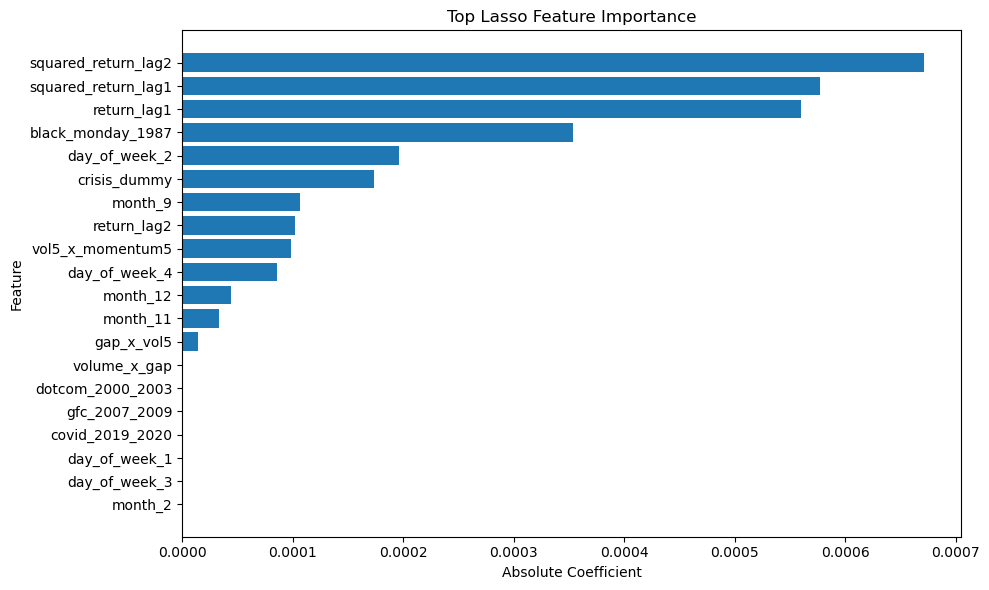

In [145]:
# ============================================================
# Plot top Lasso features
# ============================================================

top_n = 20
top_lasso = lasso_importance.head(top_n).sort_values("AbsCoefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_lasso["Feature"], top_lasso["AbsCoefficient"])
plt.title("Top Lasso Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [146]:
# ============================================================
# Ridge coefficients
# ============================================================

ridge_pipeline = models["Ridge Regression"]
ridge_pipeline.fit(X_train, y_train)

ridge_coef = ridge_pipeline.named_steps["model"].coef_

ridge_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge_coef
})

ridge_importance["AbsCoefficient"] = ridge_importance["Coefficient"].abs()

ridge_importance = ridge_importance.sort_values(
    "AbsCoefficient",
    ascending=False
).reset_index(drop=True)

ridge_importance.head(20)

,Feature,Coefficient,AbsCoefficient
0,rolling_mean_5,-0.013582,0.013582
1,momentum_5,0.013125,0.013125
2,squared_return_lag2,0.001437,0.001437
3,momentum_10,-0.001432,0.001432
4,squared_return_lag1,0.001130,0.001130
5,rolling_mean_10,0.001094,0.001094
6,return_lag1,0.000810,0.000810
7,gap,0.000802,0.000802
8,vol5_x_momentum5,0.000772,0.000772
9,volume_x_abs_return_lag1,-0.000684,0.000684


In [147]:
# ============================================================
# PCA explained variance
# ============================================================

pca_pipeline = models["PCA + Linear Regression"]
pca_pipeline.fit(X_train, y_train)

pca = pca_pipeline.named_steps["pca"]

print("Number of selected components:", pca.n_components_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

pca_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(pca.explained_variance_ratio_)
})

pca_variance.head(20)

Number of selected components: 32
Total explained variance: 0.9521004810895994


,PC,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.143356,0.143356
1,PC2,0.099564,0.242921
2,PC3,0.059951,0.302872
3,PC4,0.051692,0.354564
4,PC5,0.038100,0.392664
5,PC6,0.036255,0.428919
6,PC7,0.029171,0.458090
7,PC8,0.027309,0.485399
8,PC9,0.026112,0.511511
9,PC10,0.025225,0.536736


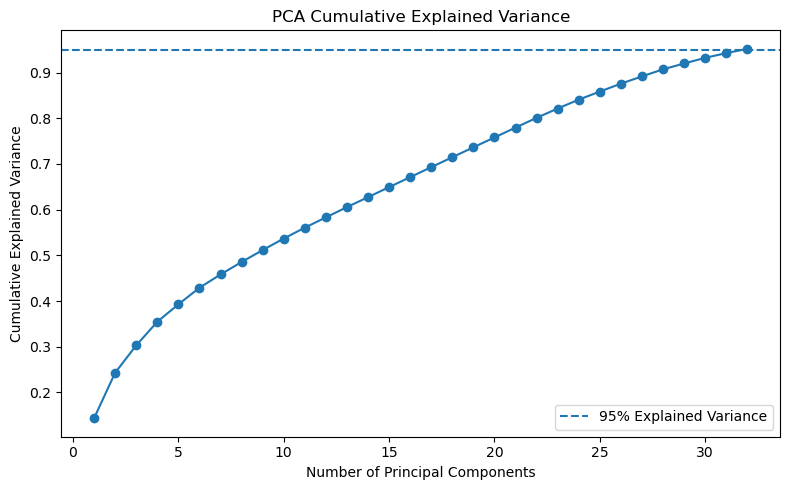

In [164]:
# ============================================================
# Plot PCA cumulative explained variance
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(y=0.95, linestyle="--", label="95% Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [165]:
# ============================================================
# Save predictions from all models
# ============================================================

predictions_df = pd.DataFrame({
    "Date": date_test.values,
    "Actual_Return": y_test.values
})

for model_name, model in models.items():
    predictions_df[model_name + "_Pred"] = model.predict(X_test)

predictions_df.head()

,Date,Actual_Return,Linear Regression_Pred,Ridge Regression_Pred,Lasso Regression_Pred,PCA + Linear Regression_Pred
0,2008-02-20,0.008341,0.000459,0.000531,-0.000147,-0.001266
1,2008-02-21,-0.012867,-0.000186,-0.000191,0.000072,-0.000785
2,2008-02-22,0.007881,-0.001442,-0.001446,-0.000941,-0.001705
3,2008-02-25,0.013813,-0.000926,-0.000862,0.000405,0.000383
4,2008-02-26,0.006918,0.000290,0.000310,0.000585,0.000284


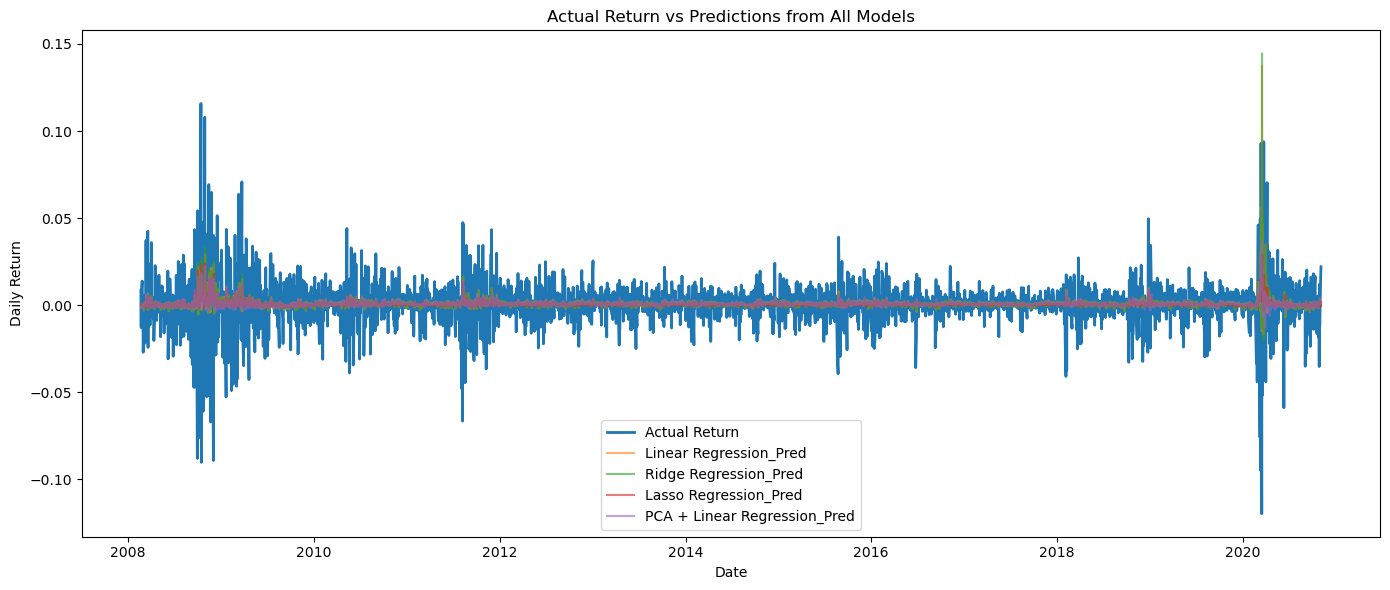

In [166]:
# 画 所有模型预测结果对比图
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(predictions_df["Date"], predictions_df["Actual_Return"], label="Actual Return", linewidth=2)

for col in predictions_df.columns:
    if col.endswith("_Pred"):
        plt.plot(predictions_df["Date"], predictions_df[col], label=col, alpha=0.6)

plt.title("Actual Return vs Predictions from All Models")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.show()

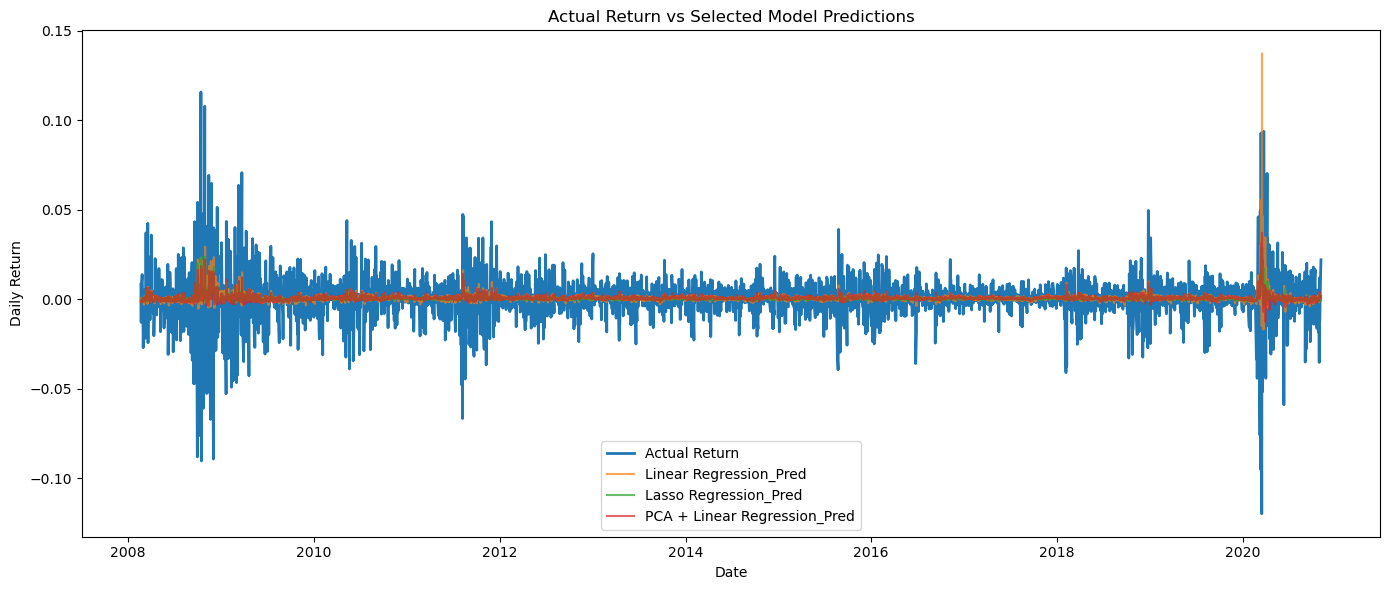

In [167]:
# 画 2~3 个代表模型
import matplotlib.pyplot as plt

selected_models = [
    "Linear Regression_Pred",
    "Lasso Regression_Pred",
    "PCA + Linear Regression_Pred"
]

plt.figure(figsize=(14, 6))
plt.plot(predictions_df["Date"], predictions_df["Actual_Return"], label="Actual Return", linewidth=2)

for col in selected_models:
    plt.plot(predictions_df["Date"], predictions_df[col], label=col, alpha=0.7)

plt.title("Actual Return vs Selected Model Predictions")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.show()

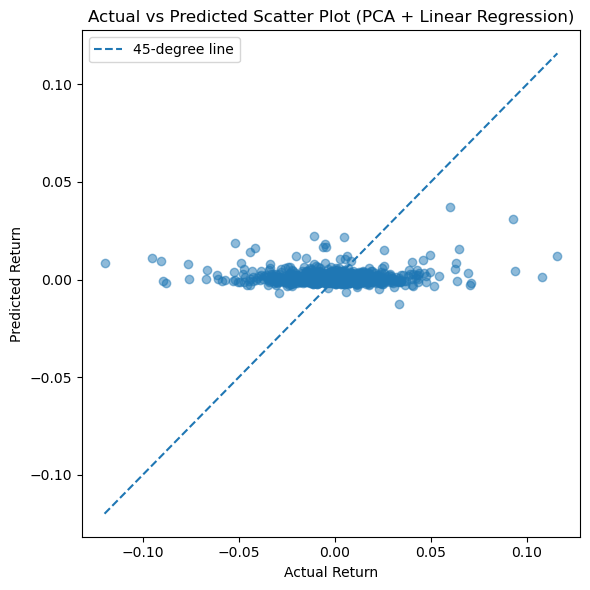

In [168]:
# 画 Actual vs Predicted 散点图
import matplotlib.pyplot as plt

best_pred_col = best_model_name + "_Pred"

plt.figure(figsize=(6, 6))
plt.scatter(predictions_df["Actual_Return"], predictions_df[best_pred_col], alpha=0.5)

min_val = min(predictions_df["Actual_Return"].min(), predictions_df[best_pred_col].min())
max_val = max(predictions_df["Actual_Return"].max(), predictions_df[best_pred_col].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="45-degree line")

plt.title(f"Actual vs Predicted Scatter Plot ({best_model_name})")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.legend()
plt.tight_layout()
plt.show()

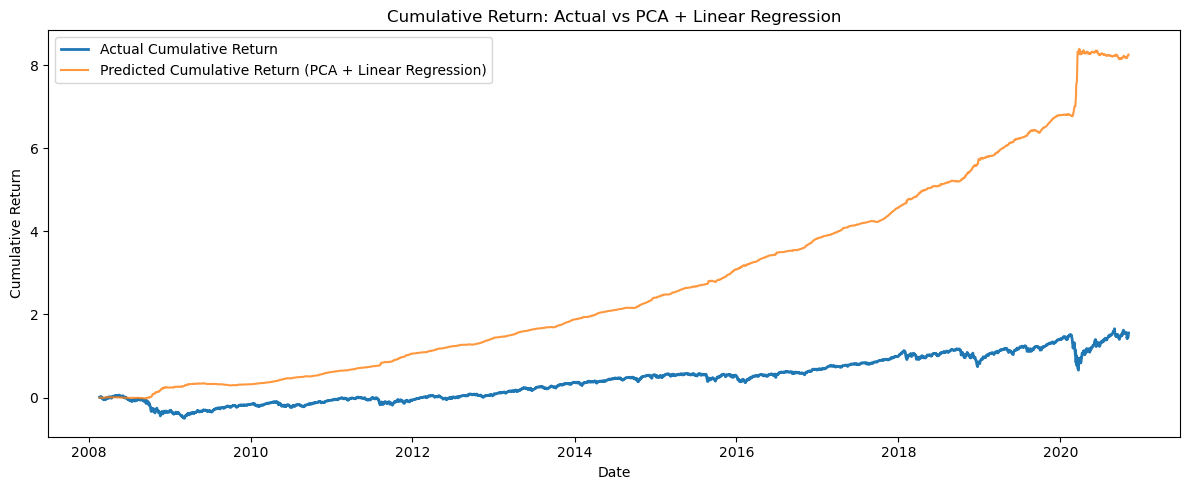

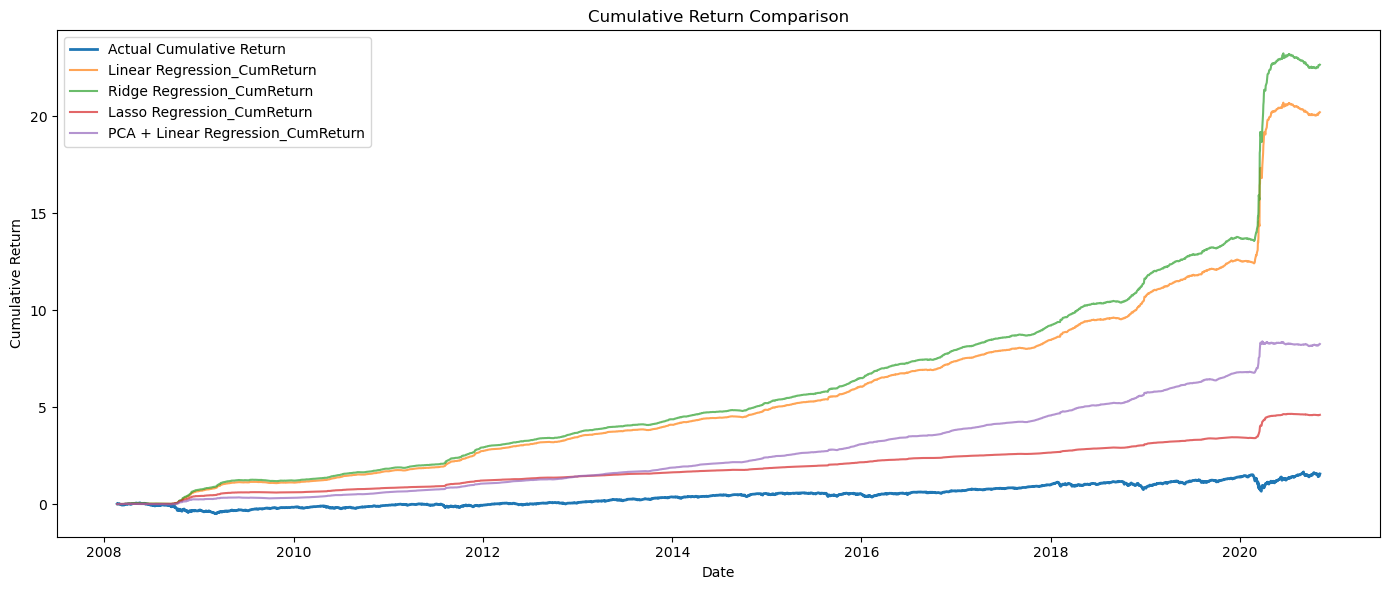

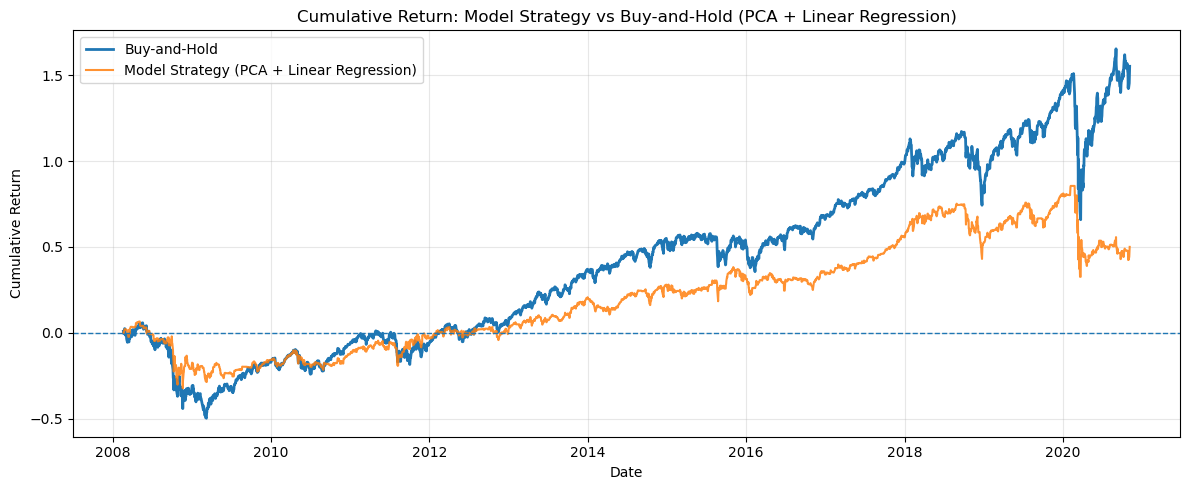

In [178]:
# 画 累计收益曲线
# ----------------

# 算cumulative return
plot_df = predictions_df.copy()

plot_df["Actual_CumReturn"] = (1 + plot_df["Actual_Return"]).cumprod() - 1

for col in plot_df.columns:
    if col.endswith("_Pred"):
        new_col = col.replace("_Pred", "_CumReturn")
        plot_df[new_col] = (1 + plot_df[col]).cumprod() - 1

# 画最佳模型累计收益
import matplotlib.pyplot as plt

best_cum_col = best_model_name + "_CumReturn"

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["Actual_CumReturn"], label="Actual Cumulative Return", linewidth=2)
plt.plot(plot_df["Date"], plot_df[best_cum_col], label=f"Predicted Cumulative Return ({best_model_name})", alpha=0.8)

plt.title(f"Cumulative Return: Actual vs {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()

# 所有模型累计收益对比
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(plot_df["Date"], plot_df["Actual_CumReturn"], label="Actual Cumulative Return", linewidth=2)

for col in plot_df.columns:
    if col.endswith("_CumReturn") and col != "Actual_CumReturn":
        plt.plot(plot_df["Date"], plot_df[col], label=col, alpha=0.7)

plt.title("Cumulative Return Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------
# Cumulative return plot: Model Strategy vs Buy-and-Hold
# ----------------

plot_df = predictions_df.copy()
plot_df = plot_df.sort_values("Date").reset_index(drop=True)

# actual buy-and-hold cumulative return
plot_df["BuyHold_Return"] = plot_df["Actual_Return"]

# choose best model prediction column
best_pred_col = best_model_name + "_Pred"

# trading signal:
# if predicted return > 0, hold the market; otherwise stay in cash
plot_df["Signal"] = (plot_df[best_pred_col] > 0).astype(int)

# strategy return
plot_df["Strategy_Return"] = plot_df["Signal"] * plot_df["Actual_Return"]

# cumulative returns
plot_df["BuyHold_CumReturn"] = (1 + plot_df["BuyHold_Return"]).cumprod() - 1
plot_df["Strategy_CumReturn"] = (1 + plot_df["Strategy_Return"]).cumprod() - 1

# plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["Date"],
    plot_df["BuyHold_CumReturn"],
    label="Buy-and-Hold",
    linewidth=2
)

plt.plot(
    plot_df["Date"],
    plot_df["Strategy_CumReturn"],
    label=f"Model Strategy ({best_model_name})",
    alpha=0.85
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Cumulative Return: Model Strategy vs Buy-and-Hold ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

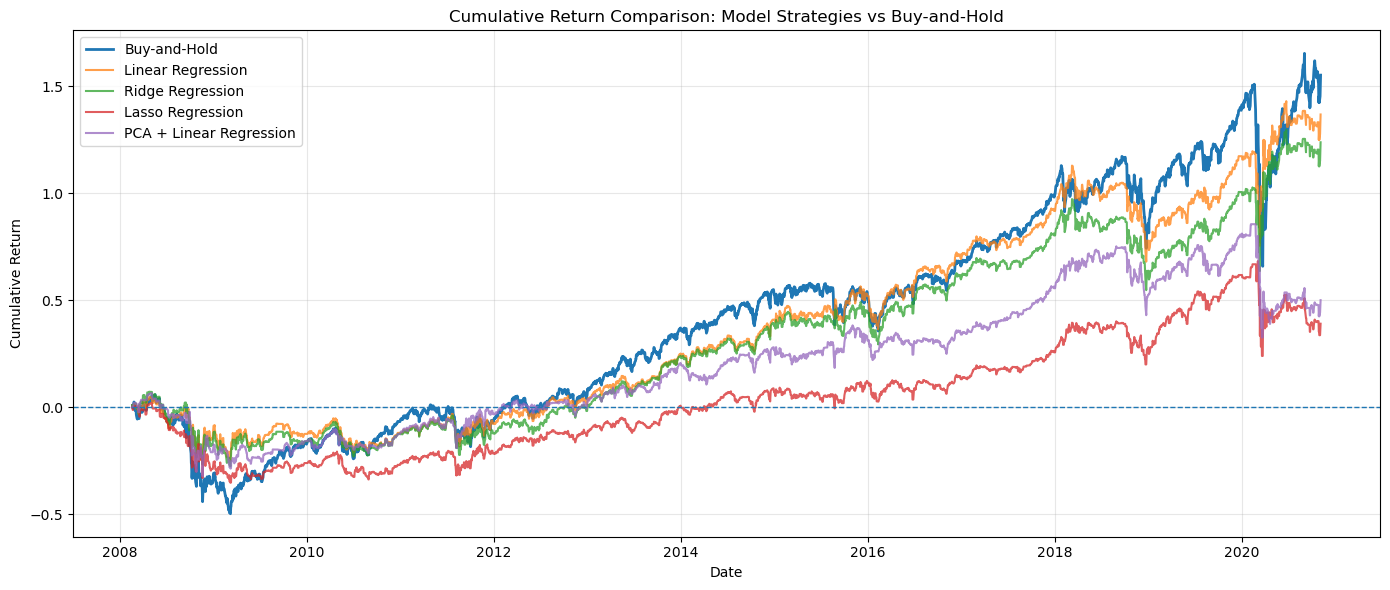

In [177]:
# # 所有模型累计收益对比
# import matplotlib.pyplot as plt

# plt.figure(figsize=(14, 6))
# plt.plot(plot_df["Date"], plot_df["Actual_CumReturn"], label="Actual Cumulative Return", linewidth=2)

# for col in plot_df.columns:
#     if col.endswith("_CumReturn") and col != "Actual_CumReturn":
#         plt.plot(plot_df["Date"], plot_df[col], label=col, alpha=0.7)

# plt.title("Cumulative Return Comparison")
# plt.xlabel("Date")
# plt.ylabel("Cumulative Return")
# plt.legend()
# plt.tight_layout()
# plt.show()

# ----------------
# 所有模型策略累计收益对比
# ----------------

import matplotlib.pyplot as plt

plot_df = predictions_df.copy()
plot_df = plot_df.sort_values("Date").reset_index(drop=True)

# Buy-and-hold cumulative return
plot_df["BuyHold_Return"] = plot_df["Actual_Return"]
plot_df["BuyHold_CumReturn"] = (1 + plot_df["BuyHold_Return"]).cumprod() - 1

# For each model prediction column, construct trading strategy return
for col in plot_df.columns:
    if col.endswith("_Pred"):
        model_name = col.replace("_Pred", "")

        signal_col = model_name + "_Signal"
        strategy_return_col = model_name + "_Strategy_Return"
        strategy_cum_col = model_name + "_Strategy_CumReturn"

        # If predicted return > 0, hold market; otherwise stay in cash
        plot_df[signal_col] = (plot_df[col] > 0).astype(int)

        # Strategy return = signal * actual return
        plot_df[strategy_return_col] = plot_df[signal_col] * plot_df["Actual_Return"]

        # Cumulative strategy return
        plot_df[strategy_cum_col] = (1 + plot_df[strategy_return_col]).cumprod() - 1


# ----------------
# Plot all model strategy cumulative returns
# ----------------

plt.figure(figsize=(14, 6))

# Benchmark: Buy-and-hold
plt.plot(
    plot_df["Date"],
    plot_df["BuyHold_CumReturn"],
    label="Buy-and-Hold",
    linewidth=2
)

# Plot all model strategies
for col in plot_df.columns:
    if col.endswith("_Strategy_CumReturn"):
        label_name = col.replace("_Strategy_CumReturn", "")
        plt.plot(
            plot_df["Date"],
            plot_df[col],
            label=label_name,
            alpha=0.75
        )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Cumulative Return Comparison: Model Strategies vs Buy-and-Hold")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [171]:
# 画预测方向是否正确
direction_plot_df = predictions_df.copy()

direction_plot_df["Actual_Direction"] = (direction_plot_df["Actual_Return"] > 0).astype(int)

for col in direction_plot_df.columns:
    if col.endswith("_Pred"):
        direction_plot_df[col.replace("_Pred", "_Direction")] = (direction_plot_df[col] > 0).astype(int)

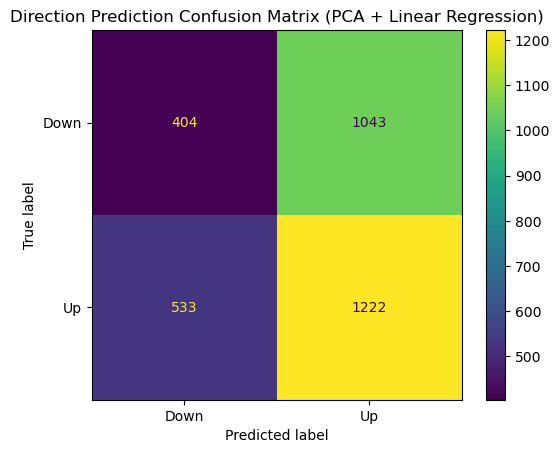

In [172]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

best_pred_col = best_model_name + "_Pred"

actual_direction = (predictions_df["Actual_Return"] > 0).astype(int)
pred_direction = (predictions_df[best_pred_col] > 0).astype(int)

cm = confusion_matrix(actual_direction, pred_direction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Down", "Up"]
)

disp.plot()
plt.title(f"Direction Prediction Confusion Matrix ({best_model_name})")
plt.show()

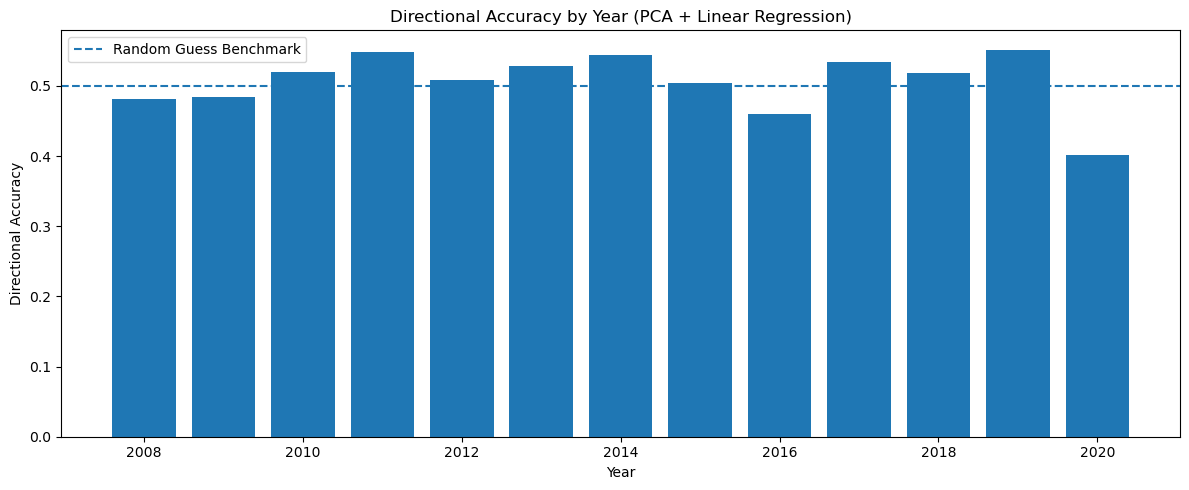

In [173]:
direction_df = predictions_df.copy()

direction_df["Year"] = pd.to_datetime(direction_df["Date"]).dt.year
direction_df["Actual_Direction"] = (direction_df["Actual_Return"] > 0).astype(int)
direction_df["Pred_Direction"] = (direction_df[best_pred_col] > 0).astype(int)
direction_df["Correct"] = (
    direction_df["Actual_Direction"] == direction_df["Pred_Direction"]
).astype(int)

yearly_acc = direction_df.groupby("Year")["Correct"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.bar(yearly_acc["Year"], yearly_acc["Correct"])
plt.axhline(0.5, linestyle="--", label="Random Guess Benchmark")
plt.title(f"Directional Accuracy by Year ({best_model_name})")
plt.xlabel("Year")
plt.ylabel("Directional Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

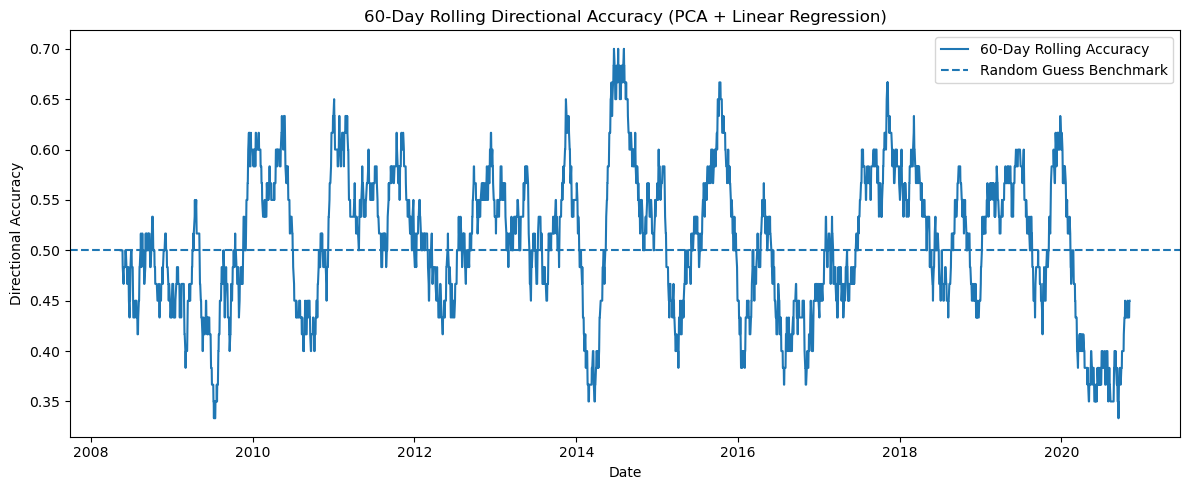

In [174]:
direction_df["Rolling_Accuracy_60D"] = direction_df["Correct"].rolling(60).mean()

plt.figure(figsize=(12, 5))
plt.plot(direction_df["Date"], direction_df["Rolling_Accuracy_60D"], label="60-Day Rolling Accuracy")
plt.axhline(0.5, linestyle="--", label="Random Guess Benchmark")
plt.title(f"60-Day Rolling Directional Accuracy ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Directional Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
direction_summary = pd.DataFrame({
    "Actual Up Ratio": [actual_direction.mean()],
    "Predicted Up Ratio": [pred_direction.mean()],
    "Directional Accuracy": [(actual_direction == pred_direction).mean()]
})

direction_summary

,Actual Up Ratio,Predicted Up Ratio,Directional Accuracy
0,0.548095,0.672705,0.503748


# 加入Explanatory Features 

In [103]:
# ============================================================
# Predictive Features vs Explanatory Features Comparison
# ============================================================

feature_sets = {
    "Predictive Features": {
        "X": X_predictive.copy(),
        "feature_names": predictive_features.copy()
    },
    "Explanatory Features": {
        "X": X_explanatory.copy(),
        "feature_names": explanatory_features.copy()
    }
}

y = df_model["target_return"].copy()

comparison_results = []
predictions_by_feature_set = {}

for feature_set_name, feature_set_info in feature_sets.items():
    
    X_current = feature_set_info["X"]
    feature_names_current = feature_set_info["feature_names"]
    
    # same time-based train/test split
    X_train_current = X_current.iloc[:split_index]
    X_test_current = X_current.iloc[split_index:]
    
    y_train_current = y.iloc[:split_index]
    y_test_current = y.iloc[split_index:]
    
    date_test_current = df_model["Date"].iloc[split_index:]
    
    # save predictions for this feature set
    pred_df = pd.DataFrame({
        "Date": date_test_current.values,
        "Actual_Return": y_test_current.values
    })
    
    for model_name, model in models.items():
        
        # fit model
        model.fit(X_train_current, y_train_current)
        
        # predict train and test
        y_train_pred = model.predict(X_train_current)
        y_test_pred = model.predict(X_test_current)
        
        # -------------------------
        # Regression metrics
        # -------------------------
        train_rmse = np.sqrt(mean_squared_error(y_train_current, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test_current, y_test_pred))
        rmse_gap = test_rmse - train_rmse
        
        train_mae = mean_absolute_error(y_train_current, y_train_pred)
        test_mae = mean_absolute_error(y_test_current, y_test_pred)
        mae_gap = test_mae - train_mae
        
        train_r2 = r2_score(y_train_current, y_train_pred)
        test_r2 = r2_score(y_test_current, y_test_pred)
        r2_gap = train_r2 - test_r2
        
        # -------------------------
        # Directional accuracy
        # -------------------------
        actual_direction = (y_test_current > 0).astype(int)
        pred_direction = (y_test_pred > 0).astype(int)
        directional_accuracy = np.mean(actual_direction == pred_direction)
        
        # -------------------------
        # Bias metrics
        # -------------------------
        prediction_error = y_test_pred - y_test_current
        
        mean_error_bias = prediction_error.mean()
        median_error = np.median(prediction_error)
        error_std = prediction_error.std()
        
        mean_actual_return = y_test_current.mean()
        mean_predicted_return = y_test_pred.mean()
        mean_return_difference = mean_predicted_return - mean_actual_return
        
        # -------------------------
        # Cumulative return path metrics
        # -------------------------
        actual_cum_return = (1 + y_test_current).cumprod() - 1
        pred_cum_return = (1 + pd.Series(y_test_pred, index=y_test_current.index)).cumprod() - 1
        
        cumulative_rmse = np.sqrt(np.mean((pred_cum_return - actual_cum_return) ** 2))
        terminal_error = pred_cum_return.iloc[-1] - actual_cum_return.iloc[-1]
        
        comparison_results.append({
            "Feature Set": feature_set_name,
            "Model": model_name,
            
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse,
            "RMSE Gap": rmse_gap,
            
            "Train MAE": train_mae,
            "Test MAE": test_mae,
            "MAE Gap": mae_gap,
            
            "Train R2": train_r2,
            "Test R2": test_r2,
            "R2 Gap": r2_gap,
            
            "Directional Accuracy": directional_accuracy,
            
            "Mean Error / Bias": mean_error_bias,
            "Median Error": median_error,
            "Error Std": error_std,
            "Mean Actual Return": mean_actual_return,
            "Mean Predicted Return": mean_predicted_return,
            "Mean Return Difference": mean_return_difference,
            
            "Cumulative RMSE": cumulative_rmse,
            "Terminal Error": terminal_error
        })
        
        pred_df[model_name + "_Pred"] = y_test_pred
    
    predictions_by_feature_set[feature_set_name] = pred_df


comparison_results_df = pd.DataFrame(comparison_results)

comparison_results_df = comparison_results_df.sort_values(
    ["Feature Set", "Test RMSE"]
).reset_index(drop=True)

comparison_results_df

,Feature Set,Model,Train RMSE,Test RMSE,RMSE Gap,Train MAE,Test MAE,MAE Gap,Train R2,Test R2,R2 Gap,Directional Accuracy,Mean Error / Bias,Median Error,Error Std,Mean Actual Return,Mean Predicted Return,Mean Return Difference,Cumulative RMSE,Terminal Error
0,Explanatory Features,Linear Regression,0.001466,0.002075,0.000609,0.000934,0.001152,0.000218,0.974296,0.975840,-0.001544,0.941599,-0.000007,-0.000013,0.002075,0.000382,0.000375,-0.000007,0.053886,0.015423
1,Explanatory Features,Ridge Regression,0.001466,0.002075,0.000609,0.000934,0.001152,0.000218,0.974293,0.975828,-0.001534,0.941287,-0.000007,-0.000011,0.002076,0.000382,0.000375,-0.000007,0.054227,0.019667
2,Explanatory Features,Lasso Regression,0.001496,0.002179,0.000683,0.000928,0.001182,0.000255,0.973222,0.973357,-0.000135,0.942536,-0.000179,-0.000170,0.002172,0.000382,0.000203,-0.000179,0.394184,-1.050944
3,Explanatory Features,PCA + Linear Regression,0.001955,0.002436,0.000481,0.001322,0.001540,0.000219,0.954295,0.966706,-0.012411,0.921299,0.000150,0.000094,0.002431,0.000382,0.000532,0.000150,0.685062,1.675731
4,Explanatory Features,PCA + Ridge Regression,0.001955,0.002436,0.000481,0.001322,0.001541,0.000219,0.954295,0.966704,-0.012409,0.921299,0.000150,0.000094,0.002432,0.000382,0.000532,0.000150,0.684967,1.675456
5,Explanatory Features,PCA + Lasso Regression,0.002006,0.002551,0.000545,0.001377,0.001606,0.000229,0.951850,0.963465,-0.011615,0.921299,0.000063,0.000010,0.002551,0.000382,0.000445,0.000063,0.394510,0.692347
6,Predictive Features,PCA + Ridge Regression,0.009058,0.013452,0.004394,0.006332,0.008355,0.002023,0.018394,-0.015642,0.034036,0.507808,0.000315,-0.000033,0.013451,0.000382,0.000697,0.000315,2.960182,6.697051
7,Predictive Features,PCA + Linear Regression,0.009058,0.013452,0.004394,0.006332,0.008355,0.002023,0.018394,-0.015643,0.034036,0.507808,0.000315,-0.000033,0.013451,0.000382,0.000697,0.000315,2.960670,6.698305
8,Predictive Features,Linear Regression,0.008996,0.013479,0.004483,0.006318,0.008347,0.002029,0.031790,-0.019676,0.051467,0.519051,0.000579,-0.000044,0.013469,0.000382,0.000961,0.000579,6.838519,18.650878
9,Predictive Features,PCA + Lasso Regression,0.009071,0.013502,0.004431,0.006333,0.008307,0.001974,0.015666,-0.023086,0.038752,0.519988,0.000268,-0.000137,0.013501,0.000382,0.000650,0.000268,2.396755,5.432463


In [104]:
# ============================================================
# Robust model selection: consider overfitting + bias + test error
# ============================================================

robust_df = comparison_results_df.copy()

# Absolute bias: 越小越好
robust_df["Abs Bias"] = robust_df["Mean Error / Bias"].abs()

# Absolute terminal error: 越小越好
robust_df["Abs Terminal Error"] = robust_df["Terminal Error"].abs()

# Overfitting ratio: 越接近 1 越好
robust_df["RMSE Ratio"] = robust_df["Test RMSE"] / robust_df["Train RMSE"]

# 如果 RMSE Ratio 很大，说明 test error 相对 train error 放大严重
robust_df["Overfit Score"] = robust_df["RMSE Gap"]

# 排除严重 overfitting 的模型
# 你可以根据结果调整阈值，比如 RMSE Gap > 0.02 就认为严重 overfit
robust_filtered = robust_df[
    robust_df["RMSE Gap"] < 0.02
].copy()

robust_filtered = robust_filtered.sort_values(
    by=["Test RMSE", "RMSE Gap", "Abs Bias", "Cumulative RMSE"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

robust_filtered[
    [
        "Feature Set",
        "Model",
        "Train RMSE",
        "Test RMSE",
        "RMSE Gap",
        "RMSE Ratio",
        "Test MAE",
        "Mean Error / Bias",
        "Abs Bias",
        "Cumulative RMSE",
        "Terminal Error",
        "Directional Accuracy"
    ]
]

,Feature Set,Model,Train RMSE,Test RMSE,RMSE Gap,RMSE Ratio,Test MAE,Mean Error / Bias,Abs Bias,Cumulative RMSE,Terminal Error,Directional Accuracy
0,Explanatory Features,Linear Regression,0.001466,0.002075,0.000609,1.415466,0.001152,-0.000007,0.000007,0.053886,0.015423,0.941599
1,Explanatory Features,Ridge Regression,0.001466,0.002075,0.000609,1.415763,0.001152,-0.000007,0.000007,0.054227,0.019667,0.941287
2,Explanatory Features,Lasso Regression,0.001496,0.002179,0.000683,1.456319,0.001182,-0.000179,0.000179,0.394184,-1.050944,0.942536
3,Explanatory Features,PCA + Linear Regression,0.001955,0.002436,0.000481,1.246113,0.001540,0.000150,0.000150,0.685062,1.675731,0.921299
4,Explanatory Features,PCA + Ridge Regression,0.001955,0.002436,0.000481,1.246148,0.001541,0.000150,0.000150,0.684967,1.675456,0.921299
5,Explanatory Features,PCA + Lasso Regression,0.002006,0.002551,0.000545,1.271778,0.001606,0.000063,0.000063,0.394510,0.692347,0.921299
6,Predictive Features,PCA + Ridge Regression,0.009058,0.013452,0.004394,1.485102,0.008355,0.000315,0.000315,2.960182,6.697051,0.507808
7,Predictive Features,PCA + Linear Regression,0.009058,0.013452,0.004394,1.485102,0.008355,0.000315,0.000315,2.960670,6.698305,0.507808
8,Predictive Features,Linear Regression,0.008996,0.013479,0.004483,1.498308,0.008347,0.000579,0.000579,6.838519,18.650878,0.519051
9,Predictive Features,PCA + Lasso Regression,0.009071,0.013502,0.004431,1.488468,0.008307,0.000268,0.000268,2.396755,5.432463,0.519988


In [105]:
# ============================================================
# Best model under each feature set
# ============================================================

best_by_feature_set = (
    comparison_results_df
    .sort_values("Test RMSE")
    .groupby("Feature Set")
    .head(1)
    .reset_index(drop=True)
)

best_by_feature_set

,Feature Set,Model,Train RMSE,Test RMSE,RMSE Gap,Train MAE,Test MAE,MAE Gap,Train R2,Test R2,R2 Gap,Directional Accuracy,Mean Error / Bias,Median Error,Error Std,Mean Actual Return,Mean Predicted Return,Mean Return Difference,Cumulative RMSE,Terminal Error
0,Explanatory Features,Linear Regression,0.001466,0.002075,0.000609,0.000934,0.001152,0.000218,0.974296,0.975840,-0.001544,0.941599,-0.000007,-0.000013,0.002075,0.000382,0.000375,-0.000007,0.053886,0.015423
1,Predictive Features,PCA + Ridge Regression,0.009058,0.013452,0.004394,0.006332,0.008355,0.002023,0.018394,-0.015642,0.034036,0.507808,0.000315,-0.000033,0.013451,0.000382,0.000697,0.000315,2.960182,6.697051


In [106]:
# ============================================================
# Model-by-model comparison table
# ============================================================

feature_set_comparison = comparison_results_df.pivot(
    index="Model",
    columns="Feature Set",
    values=[
        "Test RMSE",
        "Test MAE",
        "Test R2",
        "Directional Accuracy",
        "Mean Error / Bias",
        "Cumulative RMSE",
        "Terminal Error"
    ]
)

feature_set_comparison

Test RMSE                      \
Feature Set             Explanatory Features Predictive Features   
Model                                                              
Lasso Regression                    0.002179            0.013579   
Linear Regression                   0.002075            0.013479   
PCA + Lasso Regression              0.002551            0.013502   
PCA + Linear Regression             0.002436            0.013452   
PCA + Ridge Regression              0.002436            0.013452   
Ridge Regression                    0.002075            0.013526   

                                    Test MAE                      \
Feature Set             Explanatory Features Predictive Features   
Model                                                              
Lasso Regression                    0.001182            0.008334   
Linear Regression                   0.001152            0.008347   
PCA + Lasso Regression              0.001606            0.008307   
PCA + Linear Regression             0.001540            0.008355   
PCA + Ridge Regression              0.001541            0.008355   
Ridge Regression                    0.001152            0.008358   

                                     Test R2                      \
Feature Set             Explanatory Features Predictive Features   
Model                                                              
Lasso Regression                    0.973357           -0.034827   
Linear Regression                   0.975840           -0.019676   
PCA + Lasso Regression              0.963465           -0.023086   
PCA + Linear Regression             0.966706           -0.015643   
PCA + Ridge Regression              0.966704           -0.015642   
Ridge Regression                    0.975828           -0.026784   

                        Directional Accuracy                      \
Feature Set             Explanatory Features Predictive Features   
Model                                                              
Lasso Regression                    0.942536            0.503748   
Linear Regression                   0.941599            0.519051   
PCA + Lasso Regression              0.921299            0.519988   
PCA + Linear Regression             0.921299            0.507808   
PCA + Ridge Regression              0.921299            0.507808   
Ridge Regression                    0.941287            0.517801   

                           Mean Error / Bias                      \
Feature Set             Explanatory Features Predictive Features   
Model                                                              
Lasso Regression                   -0.000179            0.000158   
Linear Regression                  -0.000007            0.000579   
PCA + Lasso Regression              0.000063            0.000268   
PCA + Linear Regression             0.000150            0.000315   
PCA + Ridge Regression              0.000150            0.000315   
Ridge Regression                   -0.000007            0.000613   

                             Cumulative RMSE                      \
Feature Set             Explanatory Features Predictive Features   
Model                                                              
Lasso Regression                    0.394184            1.575643   
Linear Regression                   0.053886            6.838519   
PCA + Lasso Regression              0.394510            2.396755   
PCA + Linear Regression             0.685062            2.960670   
PCA + Ridge Regression              0.684967            2.960182   
Ridge Regression                    0.054227            7.570483   

                              Terminal Error                      
Feature Set             Explanatory Features Predictive Features  
Model                                                             
Lasso Regression                   -1.050944            3.045932  
Linear Regression                   0.015423           18.650878  
PCA + Lasso Regression

Improvement = Predictive Features result - Explanatory Features result

In [107]:
# ============================================================
# Improvement from Predictive Features to Explanatory Features
# ============================================================

improvement_results = []

for model_name in models.keys():
    
    predictive_row = comparison_results_df[
        (comparison_results_df["Feature Set"] == "Predictive Features") &
        (comparison_results_df["Model"] == model_name)
    ].iloc[0]
    
    explanatory_row = comparison_results_df[
        (comparison_results_df["Feature Set"] == "Explanatory Features") &
        (comparison_results_df["Model"] == model_name)
    ].iloc[0]
    
    improvement_results.append({
        "Model": model_name,
        
        "Predictive Test RMSE": predictive_row["Test RMSE"],
        "Explanatory Test RMSE": explanatory_row["Test RMSE"],
        "RMSE Improvement": predictive_row["Test RMSE"] - explanatory_row["Test RMSE"],
        
        "Predictive Test MAE": predictive_row["Test MAE"],
        "Explanatory Test MAE": explanatory_row["Test MAE"],
        "MAE Improvement": predictive_row["Test MAE"] - explanatory_row["Test MAE"],
        
        "Predictive Test R2": predictive_row["Test R2"],
        "Explanatory Test R2": explanatory_row["Test R2"],
        "R2 Improvement": explanatory_row["Test R2"] - predictive_row["Test R2"],
        
        "Predictive Directional Accuracy": predictive_row["Directional Accuracy"],
        "Explanatory Directional Accuracy": explanatory_row["Directional Accuracy"],
        "Directional Accuracy Improvement": (
            explanatory_row["Directional Accuracy"] - predictive_row["Directional Accuracy"]
        ),
        
        "Predictive Bias": predictive_row["Mean Error / Bias"],
        "Explanatory Bias": explanatory_row["Mean Error / Bias"],
        "Bias Difference": explanatory_row["Mean Error / Bias"] - predictive_row["Mean Error / Bias"],
        
        "Predictive Cumulative RMSE": predictive_row["Cumulative RMSE"],
        "Explanatory Cumulative RMSE": explanatory_row["Cumulative RMSE"],
        "Cumulative RMSE Improvement": (
            predictive_row["Cumulative RMSE"] - explanatory_row["Cumulative RMSE"]
        )
    })

improvement_df = pd.DataFrame(improvement_results)
improvement_df = improvement_df.sort_values("RMSE Improvement", ascending=False).reset_index(drop=True)

improvement_df

,Model,Predictive Test RMSE,Explanatory Test RMSE,RMSE Improvement,Predictive Test MAE,Explanatory Test MAE,MAE Improvement,Predictive Test R2,Explanatory Test R2,R2 Improvement,Predictive Directional Accuracy,Explanatory Directional Accuracy,Directional Accuracy Improvement,Predictive Bias,Explanatory Bias,Bias Difference,Predictive Cumulative RMSE,Explanatory Cumulative RMSE,Cumulative RMSE Improvement
0,Ridge Regression,0.013526,0.002075,0.011451,0.008358,0.001152,0.007206,-0.026784,0.975828,1.002611,0.517801,0.941287,0.423485,0.000613,-0.000007,-0.000620,7.570483,0.054227,7.516256
1,Linear Regression,0.013479,0.002075,0.011404,0.008347,0.001152,0.007195,-0.019676,0.975840,0.995516,0.519051,0.941599,0.422548,0.000579,-0.000007,-0.000586,6.838519,0.053886,6.784633
2,Lasso Regression,0.013579,0.002179,0.011400,0.008334,0.001182,0.007151,-0.034827,0.973357,1.008184,0.503748,0.942536,0.438788,0.000158,-0.000179,-0.000337,1.575643,0.394184,1.181459
3,PCA + Linear Regression,0.013452,0.002436,0.011017,0.008355,0.001540,0.006815,-0.015643,0.966706,0.982348,0.507808,0.921299,0.413492,0.000315,0.000150,-0.000165,2.960670,0.685062,2.275608
4,PCA + Ridge Regression,0.013452,0.002436,0.011017,0.008355,0.001541,0.006815,-0.015642,0.966704,0.982346,0.507808,0.921299,0.413492,0.000315,0.000150,-0.000165,2.960182,0.684967,2.275216
5,PCA + Lasso Regression,0.013502,0.002551,0.010950,0.008307,0.001606,0.006701,-0.023086,0.963465,0.986551,0.519988,0.921299,0.401312,0.000268,0.000063,-0.000205,2.396755,0.394510,2.002246


<Figure size 1200x500 with 0 Axes>

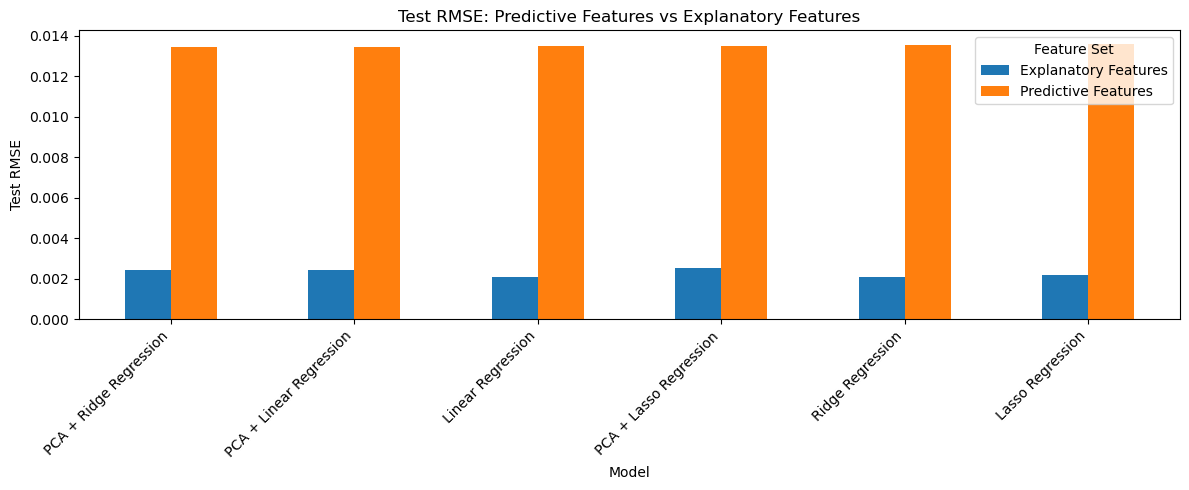

In [108]:
# ============================================================
# Plot: Test RMSE comparison
# ============================================================

rmse_plot_df = comparison_results_df.pivot(
    index="Model",
    columns="Feature Set",
    values="Test RMSE"
)

rmse_plot_df = rmse_plot_df.sort_values("Predictive Features")

plt.figure(figsize=(12, 5))
rmse_plot_df.plot(kind="bar", figsize=(12, 5))

plt.title("Test RMSE: Predictive Features vs Explanatory Features")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

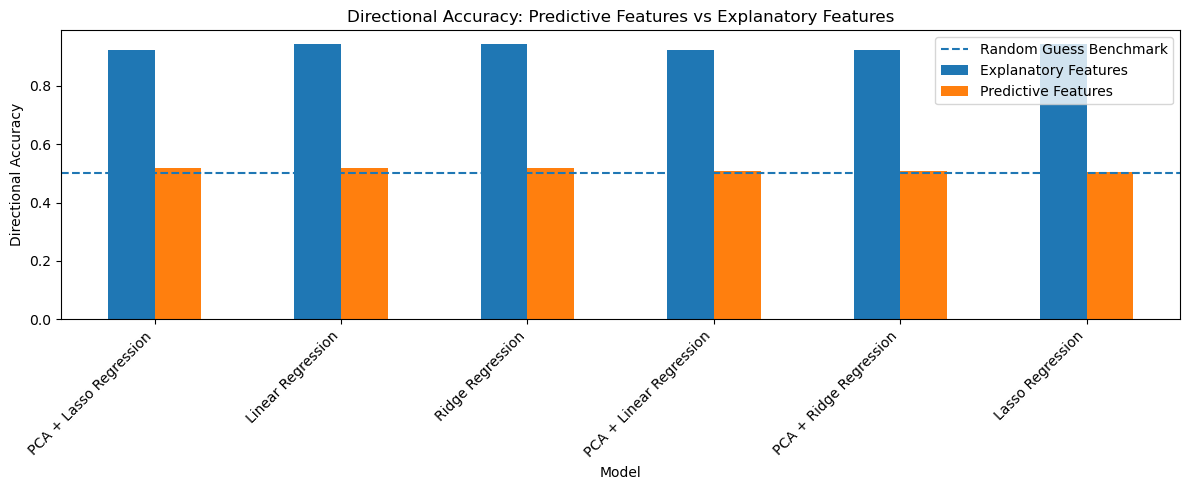

In [109]:
# ============================================================
# Plot: Directional Accuracy comparison
# ============================================================

direction_plot_df = comparison_results_df.pivot(
    index="Model",
    columns="Feature Set",
    values="Directional Accuracy"
)

direction_plot_df = direction_plot_df.sort_values("Predictive Features", ascending=False)

plt.figure(figsize=(12, 5))
direction_plot_df.plot(kind="bar", figsize=(12, 5))

plt.axhline(0.5, linestyle="--", label="Random Guess Benchmark")
plt.title("Directional Accuracy: Predictive Features vs Explanatory Features")
plt.xlabel("Model")
plt.ylabel("Directional Accuracy")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

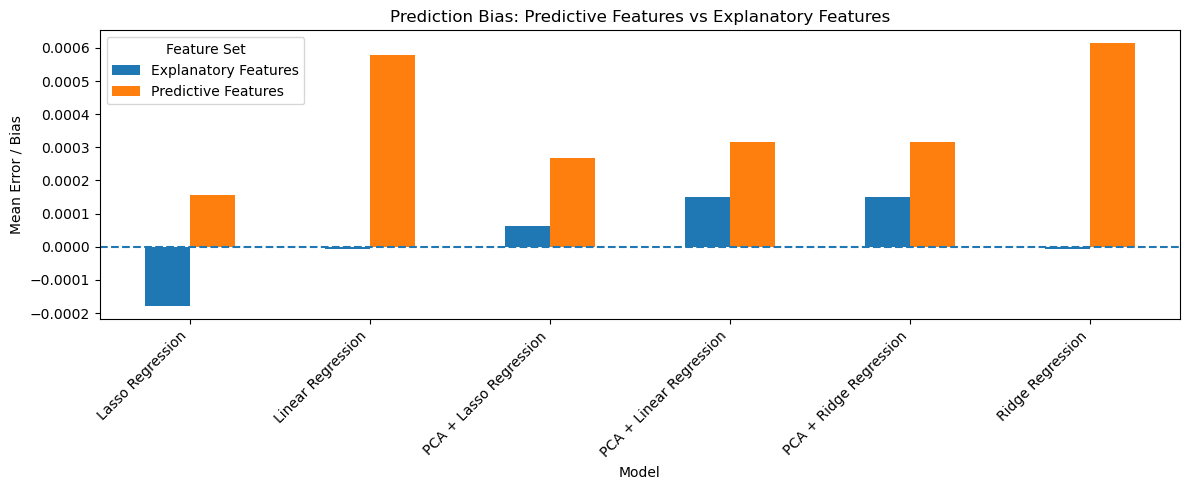

In [110]:
# ============================================================
# Plot: Mean Error / Bias comparison
# ============================================================

bias_plot_df = comparison_results_df.pivot(
    index="Model",
    columns="Feature Set",
    values="Mean Error / Bias"
)

plt.figure(figsize=(12, 5))
bias_plot_df.plot(kind="bar", figsize=(12, 5))

plt.axhline(0, linestyle="--")
plt.title("Prediction Bias: Predictive Features vs Explanatory Features")
plt.xlabel("Model")
plt.ylabel("Mean Error / Bias")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

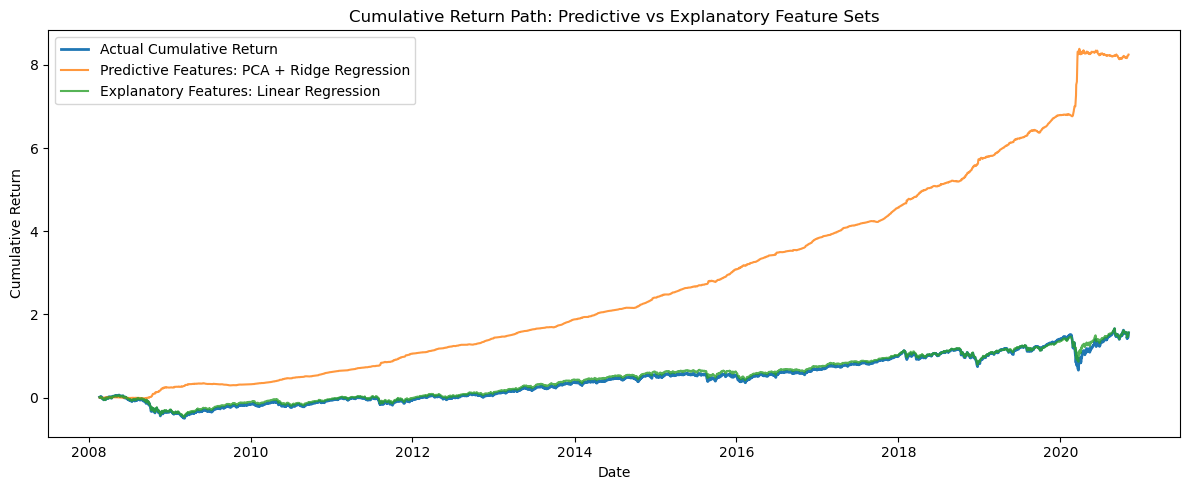

In [111]:
# ============================================================
# Plot cumulative return path for best model in each feature set
# ============================================================

plt.figure(figsize=(12, 5))

# actual cumulative return
actual_df = predictions_by_feature_set["Predictive Features"].copy()
actual_df["Actual_CumReturn"] = (1 + actual_df["Actual_Return"]).cumprod() - 1

plt.plot(
    actual_df["Date"],
    actual_df["Actual_CumReturn"],
    label="Actual Cumulative Return",
    linewidth=2
)

for feature_set_name in feature_sets.keys():
    
    best_model_name_current = best_by_feature_set[
        best_by_feature_set["Feature Set"] == feature_set_name
    ]["Model"].iloc[0]
    
    pred_df = predictions_by_feature_set[feature_set_name].copy()
    pred_col = best_model_name_current + "_Pred"
    
    pred_df["Pred_CumReturn"] = (1 + pred_df[pred_col]).cumprod() - 1
    
    plt.plot(
        pred_df["Date"],
        pred_df["Pred_CumReturn"],
        label=f"{feature_set_name}: {best_model_name_current}",
        alpha=0.8
    )

plt.title("Cumulative Return Path: Predictive vs Explanatory Feature Sets")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()

In [112]:
# ============================================================
# Lasso feature importance under both feature sets
# ============================================================

lasso_importance_by_feature_set = {}

for feature_set_name, feature_set_info in feature_sets.items():
    
    X_current = feature_set_info["X"]
    feature_names_current = feature_set_info["feature_names"]
    
    X_train_current = X_current.iloc[:split_index]
    y_train_current = y.iloc[:split_index]
    
    lasso_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0001, max_iter=10000))
    ])
    
    lasso_pipeline.fit(X_train_current, y_train_current)
    
    lasso_coef = lasso_pipeline.named_steps["model"].coef_
    
    lasso_importance_current = pd.DataFrame({
        "Feature": feature_names_current,
        "Coefficient": lasso_coef
    })
    
    lasso_importance_current["AbsCoefficient"] = (
        lasso_importance_current["Coefficient"].abs()
    )
    
    lasso_importance_current = lasso_importance_current.sort_values(
        "AbsCoefficient",
        ascending=False
    ).reset_index(drop=True)
    
    lasso_importance_by_feature_set[feature_set_name] = lasso_importance_current


lasso_importance_by_feature_set["Predictive Features"].head(20)

,Feature,Coefficient,AbsCoefficient
0,squared_return_lag2,0.000672,0.000672
1,squared_return_lag1,0.000578,0.000578
2,return_lag1,0.000560,0.000560
3,black_monday_1987,-0.000354,0.000354
4,day_of_week_2,0.000196,0.000196
5,crisis_dummy,-0.000174,0.000174
6,month_9,-0.000106,0.000106
7,return_lag2,-0.000102,0.000102
8,vol5_x_momentum5,0.000098,0.000098
9,day_of_week_4,0.000086,0.000086


In [113]:
# ============================================================
# Check explanatory-only features selected by Lasso
# ============================================================

explanatory_only_features = [
    feature for feature in explanatory_features
    if feature not in predictive_features
]

explanatory_lasso_importance = lasso_importance_by_feature_set["Explanatory Features"]

explanatory_only_lasso = explanatory_lasso_importance[
    explanatory_lasso_importance["Feature"].isin(explanatory_only_features)
].sort_values("AbsCoefficient", ascending=False).reset_index(drop=True)

explanatory_only_lasso

,Feature,Coefficient,AbsCoefficient
0,intraday_return,0.006386,0.006386
1,low_return_from_prev_close,0.001805,0.001805
2,high_return_from_prev_close,0.001748,0.001748
3,high_low_range,-0.000000,0.000000
4,range_x_vol5,0.000000,0.000000


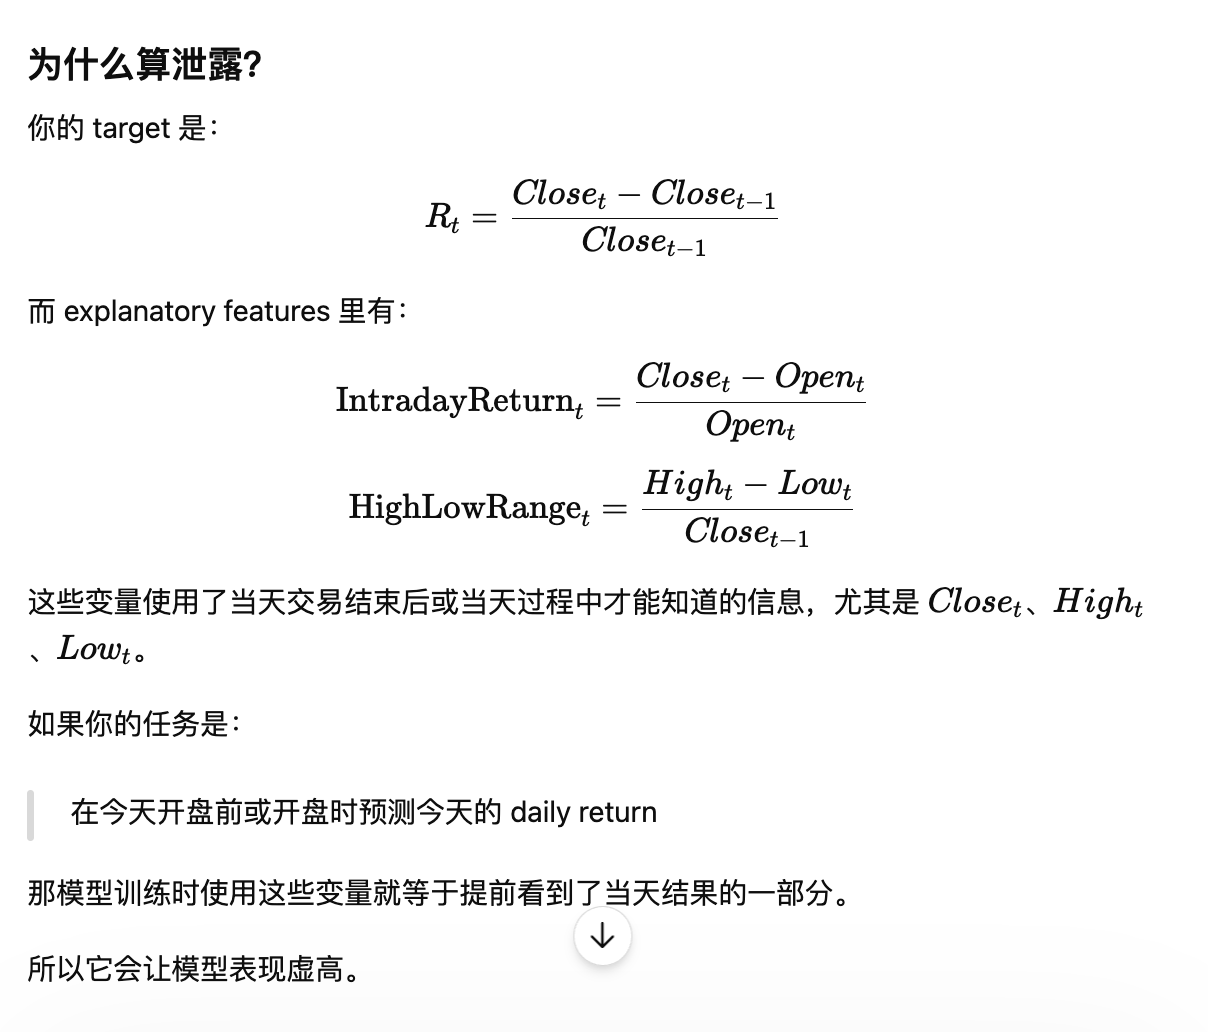

Explanatory features are valid for explaining realized daily returns, but not valid for forecasting them before they are realized.

# Multi-Frequency Return Prediction: Daily, Weekly, Monthly, and Quarterly

This section extends the original daily-return prediction notebook to multiple investment horizons.  
The original daily OHLCV data are first resampled into weekly, monthly, and quarterly frequency. For each frequency:

- Open = first opening price in the period
- High = maximum high price in the period
- Low = minimum low price in the period
- Close = last closing price in the period
- Volume = total trading volume in the period

Then the same feature engineering and time-based train/test prediction pipeline is applied separately to each frequency.


In [121]:
# ============================================================
# Multi-Frequency Prediction Setup
# Daily / Weekly / Monthly / Quarterly
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reload original cleaned daily data to avoid being affected by previous cells
raw_df = pd.read_csv("data_cleaned.csv")
raw_df["Date"] = pd.to_datetime(raw_df["Date"])
raw_df = raw_df.sort_values("Date").reset_index(drop=True)

print(raw_df.shape)
raw_df.head()


(16031, 6)


,Date,Open,High,Low,Close,Volume
0,1957-03-04,44.060001,44.060001,44.060001,44.060001,1890000
1,1957-03-05,44.220001,44.220001,44.220001,44.220001,1860000
2,1957-03-06,44.230000,44.230000,44.230000,44.230000,1840000
3,1957-03-07,44.209999,44.209999,44.209999,44.209999,1830000
4,1957-03-08,44.070000,44.070000,44.070000,44.070000,1630000


In [122]:
# ============================================================
# Resample OHLCV data into different investment horizons
# ============================================================

def resample_ohlcv(df, freq):
    """
    Convert daily OHLCV data into a lower frequency.

    freq options:
    - "D"  : daily baseline
    - "W"  : weekly
    - "M"  : monthly
    - "Q"  : quarterly
    """
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").set_index("Date")

    # Daily baseline does not need aggregation
    if freq == "D":
        return df.reset_index()

    out = pd.DataFrame()
    out["Open"] = df["Open"].resample(freq).first()
    out["High"] = df["High"].resample(freq).max()
    out["Low"] = df["Low"].resample(freq).min()
    out["Close"] = df["Close"].resample(freq).last()
    out["Volume"] = df["Volume"].resample(freq).sum()

    out = out.dropna().reset_index()
    return out

frequency_map = {
    "Daily": "D",
    "Weekly": "W",
    "Monthly": "M",
    "Quarterly": "Q"
}

resampled_preview = []
for freq_name, freq_code in frequency_map.items():
    tmp = resample_ohlcv(raw_df, freq_code)
    resampled_preview.append({
        "Frequency": freq_name,
        "Rows": len(tmp),
        "Start Date": tmp["Date"].min(),
        "End Date": tmp["Date"].max()
    })

pd.DataFrame(resampled_preview)


/var/folders/_7/km33wm3x73x0k3yxhnf41zf80000gn/T/ipykernel_2277/2516246746.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  out["Open"] = df["Open"].resample(freq).first()
/var/folders/_7/km33wm3x73x0k3yxhnf41zf80000gn/T/ipykernel_2277/2516246746.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  out["High"] = df["High"].resample(freq).max()
/var/folders/_7/km33wm3x73x0k3yxhnf41zf80000gn/T/ipykernel_2277/2516246746.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  out["Low"] = df["Low"].resample(freq).min()
/var/folders/_7/km33wm3x73x0k3yxhnf41zf80000gn/T/ipykernel_2277/2516246746.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  out["Close"] = df["Close"].resample(freq).last()
/var/folders/_7/km33wm3x73x0k3yxhnf41zf80000gn/T/ipykernel_2277/2516246746.py:28:

,Frequency,Rows,Start Date,End Date
0,Daily,16031,1957-03-04,2020-11-04
1,Weekly,3323,1957-03-10,2020-11-08
2,Monthly,765,1957-03-31,2020-11-30
3,Quarterly,256,1957-03-31,2020-12-31


In [123]:
# ============================================================
# Feature engineering function for any frequency
# ============================================================

def create_return_features(df):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # Basic period returns
    df["openReturn"] = df["Open"].pct_change()
    df["highReturn"] = df["High"].pct_change()
    df["lowReturn"] = df["Low"].pct_change()
    df["closeReturn"] = df["Close"].pct_change()
    df["volumeChange"] = df["Volume"].pct_change()

    # Target: return of the current period
    df["target_return"] = df["Close"].pct_change()

    # Price structure features
    df["gap"] = (df["Open"].shift(1) - df["Close"].shift(2)) / df["Close"].shift(2)
    df["intraday_return"] = (df["Close"] - df["Open"]) / df["Open"]
    df["high_low_range"] = (df["High"] - df["Low"]) / df["Close"].shift(1)
    df["high_return_from_prev_close"] = (df["High"] - df["Close"].shift(1)) / df["Close"].shift(1)
    df["low_return_from_prev_close"] = (df["Low"] - df["Close"].shift(1)) / df["Close"].shift(1)

    # Lagged return features
    for lag in [1, 2, 3, 5, 10]:
        df[f"return_lag{lag}"] = df["target_return"].shift(lag)

    # Rolling features
    for window in [5, 10, 20]:
        df[f"rolling_mean_{window}"] = df["target_return"].shift(1).rolling(window).mean()
        df[f"rolling_vol_{window}"] = df["target_return"].shift(1).rolling(window).std()

    df["rolling_max_5"] = df["target_return"].shift(1).rolling(5).max()
    df["rolling_min_5"] = df["target_return"].shift(1).rolling(5).min()

    # Momentum
    df["momentum_5"] = df["Close"].pct_change(5).shift(1)
    df["momentum_10"] = df["Close"].pct_change(10).shift(1)

    # Nonlinear features
    df["squared_return_lag1"] = df["return_lag1"] ** 2
    df["squared_return_lag2"] = df["return_lag2"] ** 2
    df["abs_return_lag1"] = df["return_lag1"].abs()
    df["abs_return_lag2"] = df["return_lag2"].abs()
    df["gap_squared"] = df["gap"] ** 2
    df["gap_x_vol5"] = df["gap"] * df["rolling_vol_5"]
    df["gap_x_momentum5"] = df["gap"] * df["momentum_5"]
    df["vol5_x_momentum5"] = df["rolling_vol_5"] * df["momentum_5"]
    df["range_x_vol5"] = df["high_low_range"] * df["rolling_vol_5"]

    # Volume-related features
    df["log_volume"] = np.log1p(df["Volume"]).shift(1)
    df["volume_change_lag1"] = df["Volume"].pct_change().shift(1)
    df["volume_ma20"] = df["Volume"].shift(1).rolling(20).mean()
    df["volume_ratio_20"] = df["Volume"].shift(1) / df["volume_ma20"]
    df["volume_spike"] = (df["volume_ratio_20"] > 1.5).astype(int)
    df["volume_zscore_20"] = (
        df["Volume"].shift(1) - df["Volume"].shift(2).rolling(20).mean()
    ) / df["Volume"].shift(2).rolling(20).std()
    df["volume_x_gap"] = df["volume_ratio_20"] * df["gap"]
    df["volume_x_abs_return_lag1"] = df["volume_ratio_20"] * df["abs_return_lag2"]

    # Crisis/event dummies
    df["crisis_dummy"] = 0
    df["black_monday_1987"] = 0
    df.loc[(df["Date"] >= "1987-10-01") & (df["Date"] <= "1987-12-31"), ["crisis_dummy", "black_monday_1987"]] = 1

    df["dotcom_2000_2003"] = 0
    df.loc[(df["Date"] >= "2000-03-01") & (df["Date"] <= "2003-12-31"), ["crisis_dummy", "dotcom_2000_2003"]] = 1

    df["gfc_2007_2009"] = 0
    df.loc[(df["Date"] >= "2007-07-01") & (df["Date"] <= "2009-06-30"), ["crisis_dummy", "gfc_2007_2009"]] = 1

    df["covid_2019_2020"] = 0
    df.loc[(df["Date"] >= "2019-12-01") & (df["Date"] <= "2020-12-31"), ["crisis_dummy", "covid_2019_2020"]] = 1

    # Calendar features
    df["day_of_week"] = df["Date"].dt.dayofweek
    df["month"] = df["Date"].dt.month
    df["year"] = df["Date"].dt.year
    df = pd.get_dummies(df, columns=["day_of_week", "month"], drop_first=True)

    # Clean invalid rows created by lag/rolling calculations
    df = df.replace([np.inf, -np.inf], np.nan)
    df_model = df.dropna().reset_index(drop=True)

    return df_model


In [127]:
# ============================================================
# Model building and evaluation functions
# ============================================================

base_predictive_features = [
    "gap",
    "return_lag1", "return_lag2", "return_lag3", "return_lag5", "return_lag10",
    "rolling_mean_5", "rolling_mean_10", "rolling_mean_20",
    "rolling_vol_5", "rolling_vol_10", "rolling_vol_20",
    "rolling_max_5", "rolling_min_5",
    "momentum_5", "momentum_10",
    "squared_return_lag1", "squared_return_lag2",
    "abs_return_lag1", "abs_return_lag2",
    "gap_squared", "gap_x_vol5", "gap_x_momentum5", "vol5_x_momentum5",
    "log_volume", "volume_change_lag1", "volume_ratio_20", "volume_spike",
    "volume_zscore_20", "volume_x_gap", "volume_x_abs_return_lag1"
]

base_explanatory_extra_features = [
    "intraday_return",
    "high_low_range",
    "high_return_from_prev_close",
    "low_return_from_prev_close",
    "range_x_vol5",
    "crisis_dummy", "black_monday_1987", "dotcom_2000_2003", "gfc_2007_2009", "covid_2019_2020"
]


def get_feature_sets(df_model):
    dummy_cols = [
        col for col in df_model.columns
        if col.startswith("day_of_week_") or col.startswith("month_")
    ]

    predictive_features = [col for col in base_predictive_features + dummy_cols if col in df_model.columns]
    explanatory_features = [
        col for col in predictive_features + base_explanatory_extra_features
        if col in df_model.columns
    ]

    return {
        "Predictive Features": predictive_features,
        "Explanatory Features": explanatory_features
    }


def build_models(n_train):
    # Make kNN safe for small quarterly samples
    k = max(1, min(10, n_train - 1))

    return {
        "Linear Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "Ridge Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0))
        ]),
        "Lasso Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=0.0001, max_iter=10000))
        ]),
        # "Polynomial Regression": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        #     ("model", Ridge(alpha=1.0))
        # ]),
        # "kNN Regression": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("model", KNeighborsRegressor(n_neighbors=k))
        # ]),
        "PCA + Linear Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model", LinearRegression())
        ]),

        "PCA + Ridge Regression": Pipeline([
        ("scaler",StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", Ridge(alpha=1.0))
    ]),
        "PCA + Lasso Regression": Pipeline([
            ("scaler",StandardScaler()),
            ("pca", PCA(n_components=0.95)),
            ("model",Lasso(alpha=0.0001, max_iter=10000))
     ])
        
    }


def evaluate_one_frequency(raw_df, freq_name, freq_code, feature_set_name="Predictive Features", split_ratio=0.8):
    period_df = resample_ohlcv(raw_df, freq_code)
    df_model = create_return_features(period_df)

    feature_sets = get_feature_sets(df_model)
    selected_features = feature_sets[feature_set_name]

    X = df_model[selected_features].copy()
    y = df_model["target_return"].copy()

    split_index = int(len(df_model) * split_ratio)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    date_train = df_model["Date"].iloc[:split_index]
    date_test = df_model["Date"].iloc[split_index:]

    models = build_models(len(X_train))

    results = []
    predictions_df = pd.DataFrame({
        "Date": date_test.values,
        "Actual_Return": y_test.values
    })

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        predictions_df[model_name + "_Pred"] = y_test_pred

        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        direction_acc = np.mean((y_test_pred > 0) == (y_test > 0))
        bias = np.mean(y_test_pred - y_test)

        actual_cum = (1 + y_test.reset_index(drop=True)).cumprod() - 1
        pred_cum = (1 + pd.Series(y_test_pred)).cumprod() - 1
        cumulative_rmse = np.sqrt(np.mean((pred_cum - actual_cum) ** 2))
        terminal_error = pred_cum.iloc[-1] - actual_cum.iloc[-1]

        results.append({
            "Frequency": freq_name,
            "Feature Set": feature_set_name,
            "Model": model_name,
            "Rows After Feature Engineering": len(df_model),
            "Train Start": date_train.min(),
            "Train End": date_train.max(),
            "Test Start": date_test.min(),
            "Test End": date_test.max(),
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse,
            "Test MAE": test_mae,
            "Test R2": test_r2,
            "RMSE Gap": test_rmse - train_rmse,
            "Directional Accuracy": direction_acc,
            "Mean Error / Bias": bias,
            "Cumulative RMSE": cumulative_rmse,
            "Terminal Error": terminal_error
        })

    results_df = pd.DataFrame(results).sort_values("Test RMSE").reset_index(drop=True)

    return {
        "frequency": freq_name,
        "freq_code": freq_code,
        "df_model": df_model,
        "features": selected_features,
        "results_df": results_df,
        "predictions_df": predictions_df,
        "models": models
    }


In [128]:
# ============================================================
# Run prediction pipeline for Daily / Weekly / Monthly / Quarterly
# ============================================================

all_frequency_outputs = {}
all_results = []

for freq_name, freq_code in frequency_map.items():
    output = evaluate_one_frequency(
        raw_df=raw_df,
        freq_name=freq_name,
        freq_code=freq_code,
        feature_set_name="Predictive Features",
        split_ratio=0.8
    )
    all_frequency_outputs[freq_name] = output
    all_results.append(output["results_df"])

multi_frequency_results_df = pd.concat(all_results, ignore_index=True)

# Show all model results across frequencies
multi_frequency_results_df.sort_values(["Frequency", "Test RMSE"]).reset_index(drop=True)


/var/folders/_7/km33wm3x73x0k3yxhnf41zf80000gn/T/ipykernel_2277/2516246746.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  out["Open"] = df["Open"].resample(freq).first()
/var/folders/_7/km33wm3x73x0k3yxhnf41zf80000gn/T/ipykernel_2277/2516246746.py:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  out["High"] = df["High"].resample(freq).max()
/var/folders/_7/km33wm3x73x0k3yxhnf41zf80000gn/T/ipykernel_2277/2516246746.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  out["Low"] = df["Low"].resample(freq).min()
/var/folders/_7/km33wm3x73x0k3yxhnf41zf80000gn/T/ipykernel_2277/2516246746.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  out["Close"] = df["Close"].resample(freq).last()
/var/folders/_7/km33wm3x73x0k3yxhnf41zf80000gn/T/ipykernel_2277/2516246746.py:28:

,Frequency,Feature Set,Model,Rows After Feature Engineering,Train Start,Train End,Test Start,Test End,Train RMSE,Test RMSE,Test MAE,Test R2,RMSE Gap,Directional Accuracy,Mean Error / Bias,Cumulative RMSE,Terminal Error
0,Daily,Predictive Features,Linear Regression,16010,1957-04-02,2008-02-19,2008-02-20,2020-11-04,0.009012,0.013397,0.008333,-0.007218,0.004385,0.509369,1.802732e-04,1.562489,3.391534
1,Daily,Predictive Features,Ridge Regression,16010,1957-04-02,2008-02-19,2008-02-20,2020-11-04,0.009013,0.013439,0.008342,-0.013628,0.004426,0.508745,2.178981e-04,1.813623,4.143786
2,Daily,Predictive Features,PCA + Ridge Regression,16010,1957-04-02,2008-02-19,2008-02-20,2020-11-04,0.009070,0.013445,0.008354,-0.014511,0.004375,0.499375,8.704000e-05,1.012655,1.915344
3,Daily,Predictive Features,PCA + Linear Regression,16010,1957-04-02,2008-02-19,2008-02-20,2020-11-04,0.009070,0.013445,0.008354,-0.014512,0.004375,0.499375,8.705362e-05,1.012724,1.915535
4,Daily,Predictive Features,PCA + Lasso Regression,16010,1957-04-02,2008-02-19,2008-02-20,2020-11-04,0.009080,0.013484,0.008312,-0.020435,0.004404,0.503435,-8.461377e-07,0.627287,0.827908
5,Daily,Predictive Features,Lasso Regression,16010,1957-04-02,2008-02-19,2008-02-20,2020-11-04,0.009061,0.013568,0.008333,-0.033109,0.004507,0.505309,1.206396e-04,1.275283,2.426000
6,Monthly,Predictive Features,Lasso Regression,744,1958-12-31,2008-06-30,2008-07-31,2020-11-30,0.039713,0.046854,0.033882,-0.078099,0.007141,0.617450,1.284080e-03,0.504598,1.009931
7,Monthly,Predictive Features,Ridge Regression,744,1958-12-31,2008-06-30,2008-07-31,2020-11-30,0.039612,0.047136,0.034074,-0.091111,0.007524,0.624161,1.742694e-03,0.544509,1.253961
8,Monthly,Predictive Features,PCA + Lasso Regression,744,1958-12-31,2008-06-30,2008-07-31,2020-11-30,0.040114,0.047351,0.033961,-0.101085,0.007238,0.651007,3.217029e-03,0.841604,2.204154
9,Monthly,Predictive Features,PCA + Ridge Regression,744,1958-12-31,2008-06-30,2008-07-31,2020-11-30,0.040110,0.047895,0.034091,-0.126514,0.007785,0.637584,3.499942e-03,0.881061,2.391104


In [129]:
# ============================================================
# Best model under each frequency
# ============================================================

best_model_by_frequency = (
    multi_frequency_results_df
    .sort_values("Test RMSE")
    .groupby("Frequency")
    .head(1)
    .reset_index(drop=True)
)

best_model_by_frequency[[
    "Frequency", "Model", "Rows After Feature Engineering",
    "Test RMSE", "Test MAE", "Test R2", "Directional Accuracy",
    "Mean Error / Bias", "Cumulative RMSE", "Terminal Error"
]]


,Frequency,Model,Rows After Feature Engineering,Test RMSE,Test MAE,Test R2,Directional Accuracy,Mean Error / Bias,Cumulative RMSE,Terminal Error
0,Daily,Linear Regression,16010,0.013397,0.008333,-0.007218,0.509369,0.000180,1.562489,3.391534
1,Weekly,Ridge Regression,3302,0.026365,0.017548,0.003376,0.559758,0.000381,0.994025,1.616075
2,Monthly,Lasso Regression,744,0.046854,0.033882,-0.078099,0.617450,0.001284,0.504598,1.009931
3,Quarterly,PCA + Ridge Regression,235,0.101885,0.065251,-0.790508,0.659574,-0.004715,0.779529,-0.714651


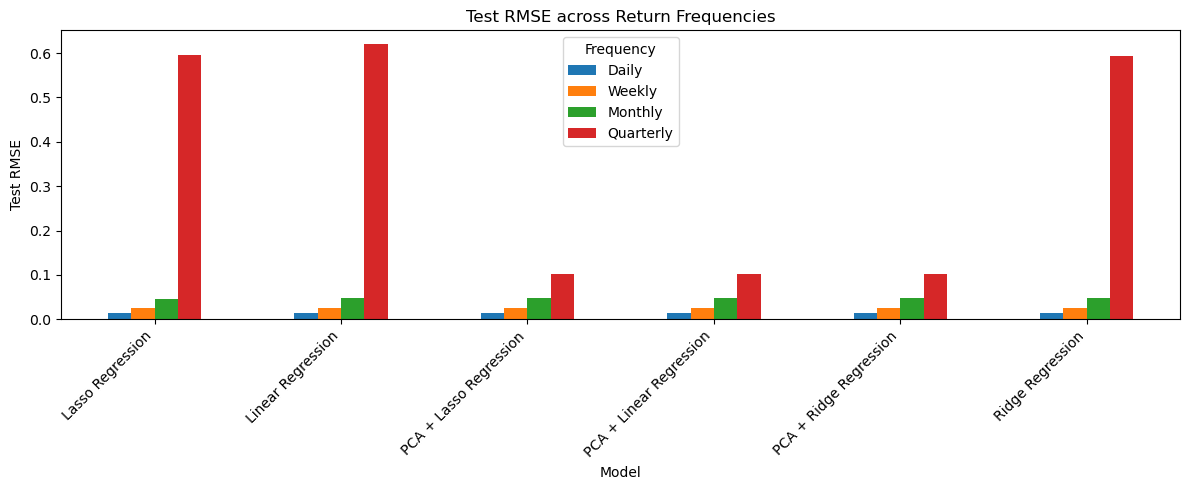

In [130]:
# ============================================================
# Plot RMSE comparison across frequencies and models
# ============================================================

rmse_pivot = multi_frequency_results_df.pivot(
    index="Model",
    columns="Frequency",
    values="Test RMSE"
)

rmse_pivot = rmse_pivot[[col for col in ["Daily", "Weekly", "Monthly", "Quarterly"] if col in rmse_pivot.columns]]

rmse_pivot.plot(kind="bar", figsize=(12, 5))
plt.title("Test RMSE across Return Frequencies")
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


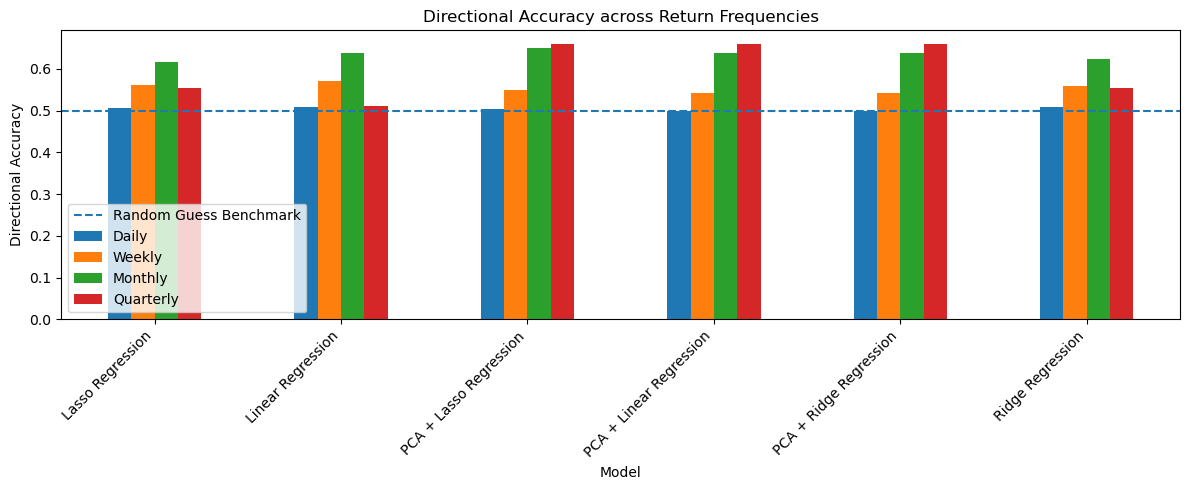

In [131]:
# ============================================================
# Plot directional accuracy comparison across frequencies and models
# ============================================================

direction_pivot = multi_frequency_results_df.pivot(
    index="Model",
    columns="Frequency",
    values="Directional Accuracy"
)

direction_pivot = direction_pivot[[col for col in ["Daily", "Weekly", "Monthly", "Quarterly"] if col in direction_pivot.columns]]

direction_pivot.plot(kind="bar", figsize=(12, 5))
plt.axhline(0.5, linestyle="--", label="Random Guess Benchmark")
plt.title("Directional Accuracy across Return Frequencies")
plt.xlabel("Model")
plt.ylabel("Directional Accuracy")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


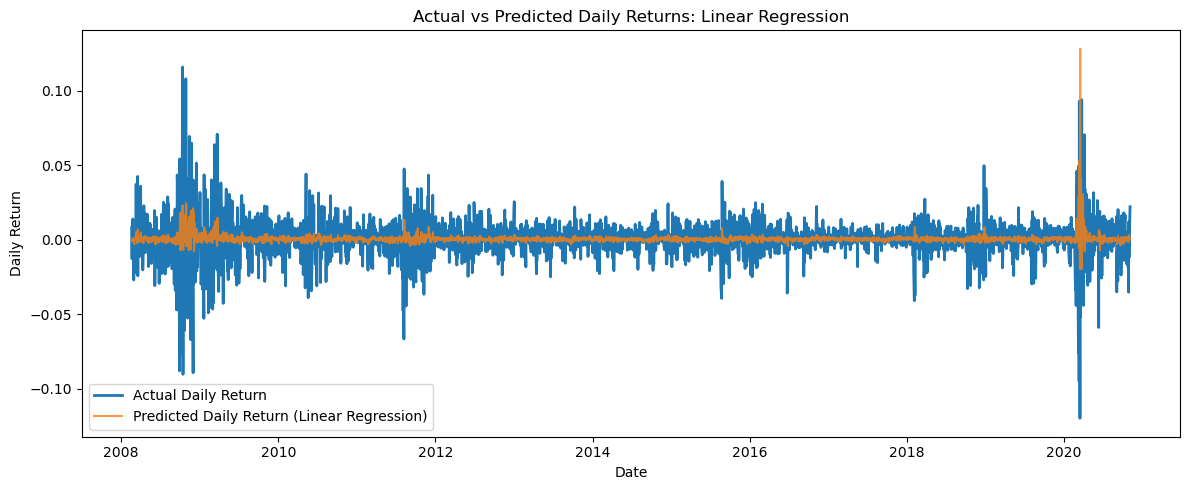

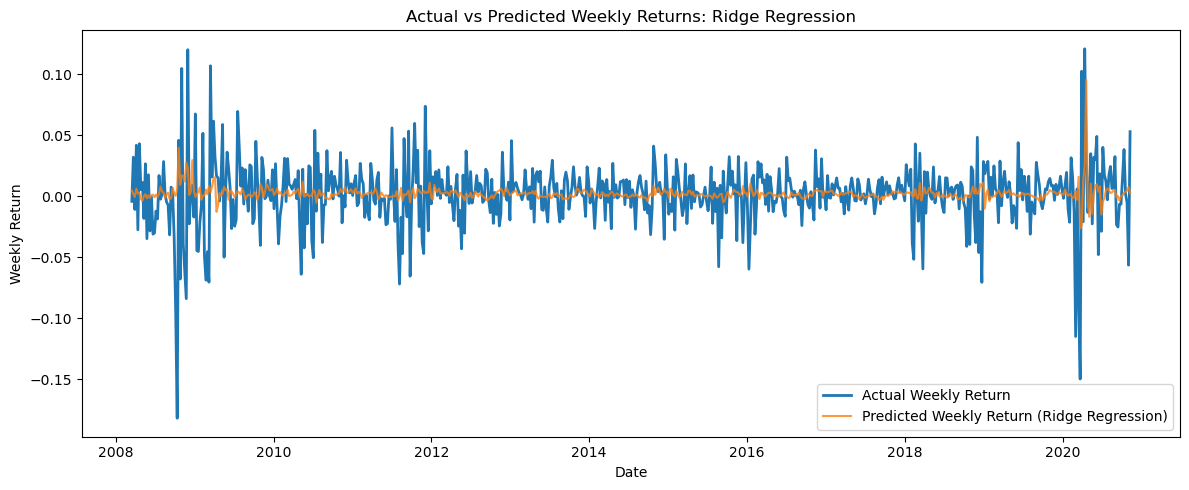

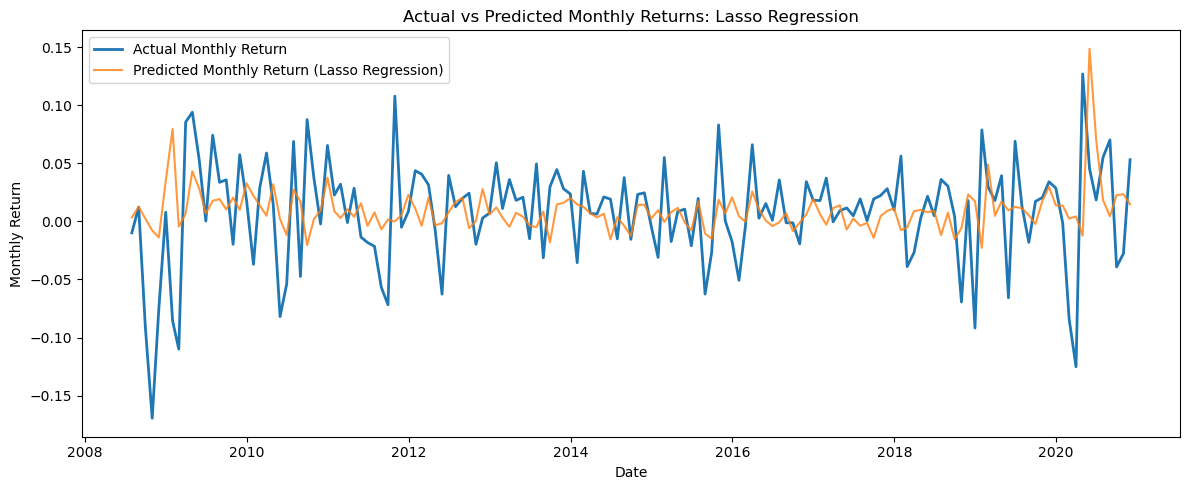

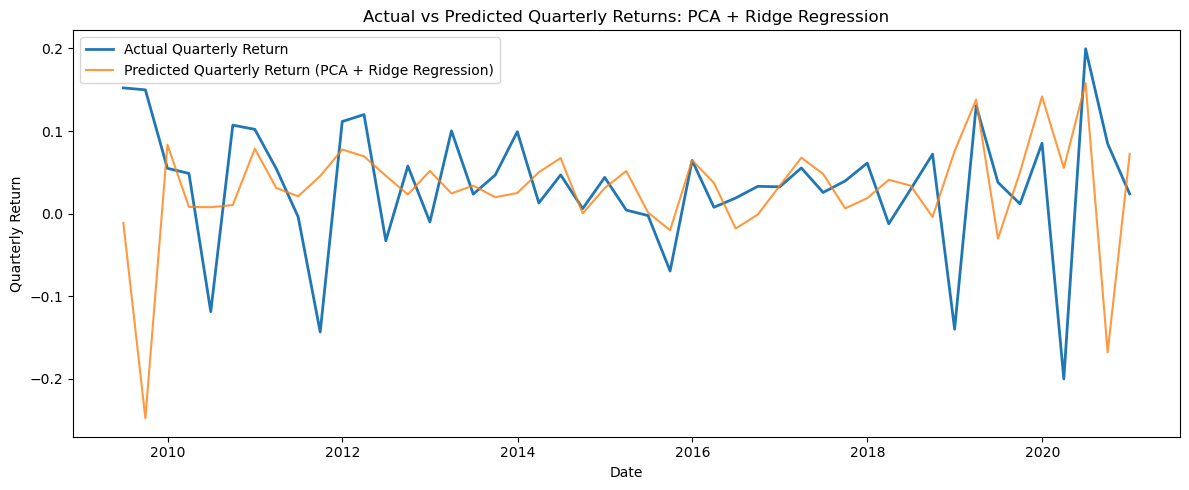

In [132]:
# ============================================================
# Plot actual vs predicted returns for the best model in each frequency
# ============================================================

for freq_name, output in all_frequency_outputs.items():
    results_df = output["results_df"]
    predictions_df = output["predictions_df"].copy()

    best_model_name = results_df.loc[0, "Model"]
    pred_col = best_model_name + "_Pred"

    plt.figure(figsize=(12, 5))
    plt.plot(predictions_df["Date"], predictions_df["Actual_Return"], label=f"Actual {freq_name} Return", linewidth=2)
    plt.plot(predictions_df["Date"], predictions_df[pred_col], label=f"Predicted {freq_name} Return ({best_model_name})", alpha=0.8)
    plt.title(f"Actual vs Predicted {freq_name} Returns: {best_model_name}")
    plt.xlabel("Date")
    plt.ylabel(f"{freq_name} Return")
    plt.legend()
    plt.tight_layout()
    plt.show()


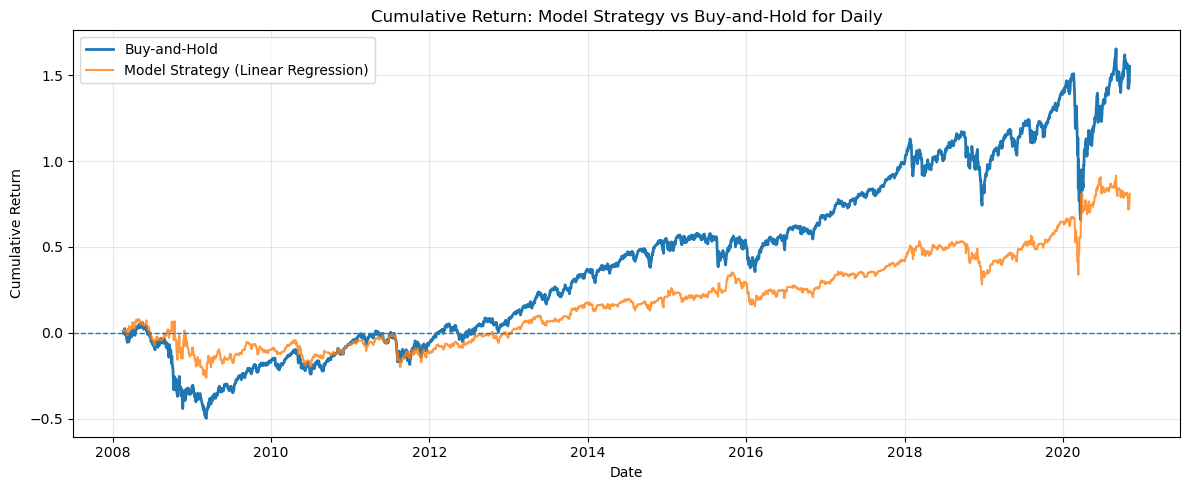

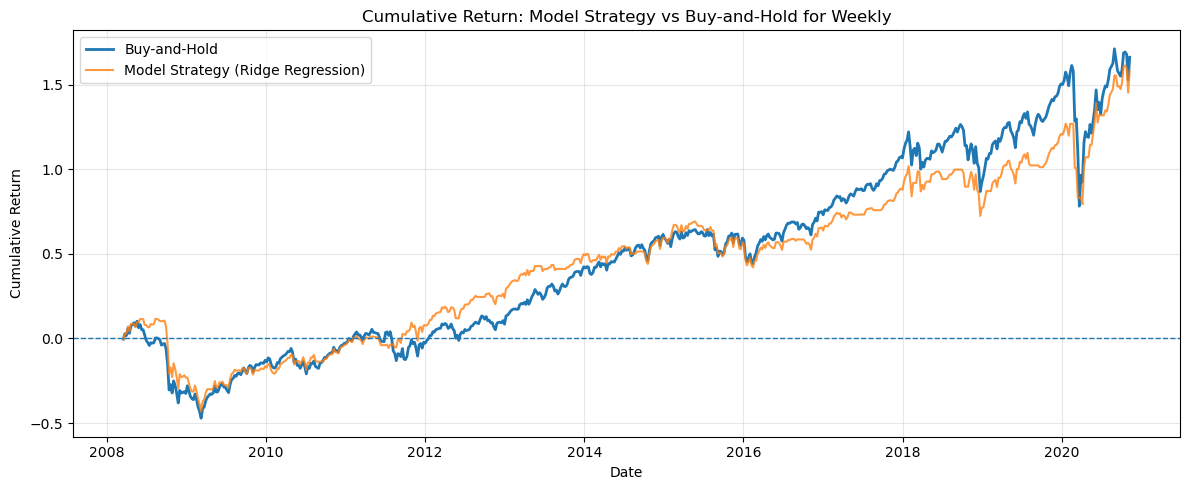

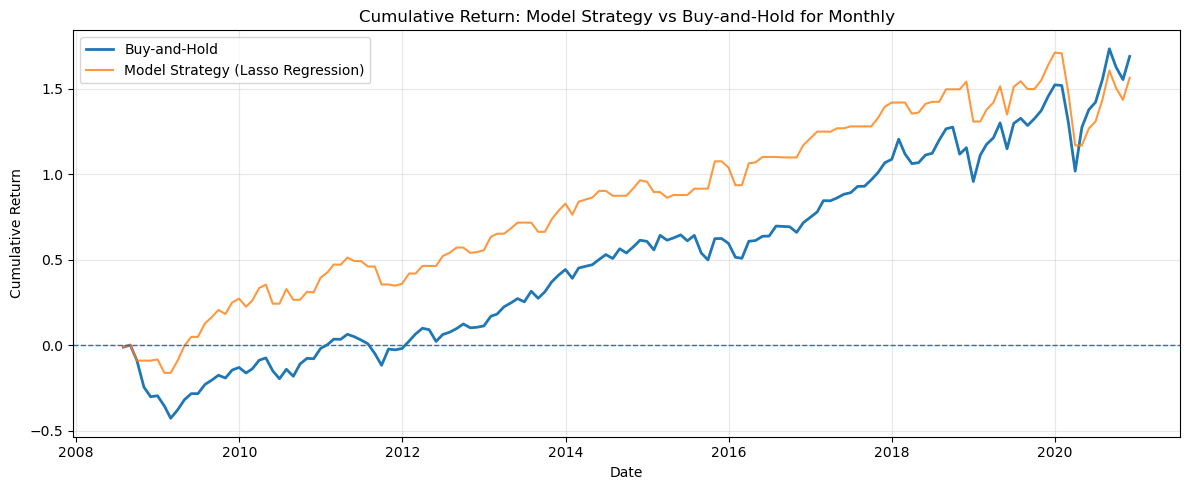

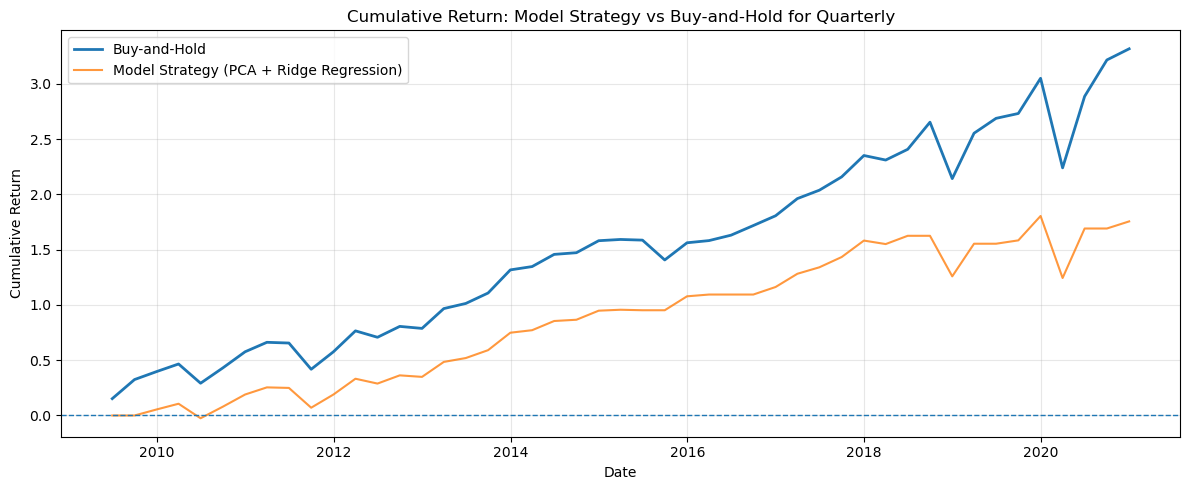

In [134]:
# ============================================================
# Plot cumulative return path for the best model in each frequency
# ============================================================

import matplotlib.pyplot as plt

for freq_name, output in all_frequency_outputs.items():
    results_df = output["results_df"]
    predictions_df = output["predictions_df"].copy()

    # make sure dates are sorted
    predictions_df = predictions_df.sort_values("Date").reset_index(drop=True)

    # best model by your results_df sorting rule
    best_model_name = results_df.loc[0, "Model"]
    pred_col = best_model_name + "_Pred"

    # -----------------------------
    # Buy-and-hold return
    # -----------------------------
    predictions_df["BuyHold_Return"] = predictions_df["Actual_Return"]
    predictions_df["BuyHold_CumReturn"] = (
        1 + predictions_df["BuyHold_Return"]
    ).cumprod() - 1

    # -----------------------------
    # Model strategy return
    # If predicted return > 0, hold market
    # Otherwise, stay in cash
    # -----------------------------
    predictions_df["Signal"] = (predictions_df[pred_col] > 0).astype(int)

    predictions_df["Strategy_Return"] = (
        predictions_df["Signal"] * predictions_df["Actual_Return"]
    )

    predictions_df["Strategy_CumReturn"] = (
        1 + predictions_df["Strategy_Return"]
    ).cumprod() - 1

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12, 5))

    plt.plot(
        predictions_df["Date"],
        predictions_df["BuyHold_CumReturn"],
        label="Buy-and-Hold",
        linewidth=2
    )

    plt.plot(
        predictions_df["Date"],
        predictions_df["Strategy_CumReturn"],
        label=f"Model Strategy ({best_model_name})",
        alpha=0.8
    )

    plt.axhline(0, linestyle="--", linewidth=1)

    plt.title(f"Cumulative Return: Model Strategy vs Buy-and-Hold for {freq_name}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()